<div style="display: flex; background-color: white" >
<h1 style="margin: auto; padding: 30px; color: grey">Étude de marché poulet bio - Analyse exploratoire (Notebook 1)</h1>
</div>

**Objectif** : Identifier les opportunités de marché pour l'export de poulet biologique.

**Approche** : 
1. Notebook 1 
<br>    > Extraction et préparation des données 
<br>    > Analyses univariées (distributions, statistiques)
<br>    > Analyses multivariées (corrélations)
2. Notebook 2
<br>    > ACP (réduction dimensionnelle)
<br>    > Clustering (deux méthodes : CAH et KMeans)


<div style="border: 1px solid white;background-color: rgb(47, 132, 171)" >
<h2 style="margin: auto; padding: 20px ; color : white">ETAPE 1 : IMPORT LIBRAIRIES ET FICHIERS</h2>
</div>

<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px; ">1.1 Import librairies</h3>
</div>

In [1]:
# Importer librairie utiles
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import numpy as np
import scipy.stats as stats
from functools import reduce

<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px; ">1.2 Chargement des fichiers</h3>
</div>

In [2]:
# Import des données
df_brut_bilan_alim_volaille = pd.read_csv("data-input/bilan_alim_volaille.csv")
df_brut_land_use = pd.read_csv("data-input/land_use.csv")
df_brut_logistic_index = pd.read_csv("data-input/logistic_index.csv", skiprows=4)
df_brut_pib_hab = pd.read_csv("data-input/pib_hab.csv", skiprows=4)
df_brut_political_stability = pd.read_csv("data-input/political_stability.csv", skiprows=4)
df_brut_population = pd.read_csv("data-input/population.csv", skiprows=4)
df_brut_unsd_isocode_fr = pd.read_csv("data-input/unsd_isocode_fr.csv")

<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px; ">1.3 Configuration (années gardées)</h3>
</div>

In [3]:
ANNEES_GARDEES = [2016, 2018, 2022] # car certaines données sont mises à jour quasi tous les 2 ans. Donc pour avoir une cohérence entre les différentes données, je garde ces années.

<div style="border: 1px solid white;background-color: rgb(47, 132, 171)" >
<h2 style="margin: auto; padding: 20px ; color : white">ETAPE 2 : STRUCTURATION ET NETTOYAGE DES FICHIERS</h2>
</div>

<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px; ">2.1 Bilan alimentaire (Volaille)</h3>
</div>

In [4]:
# Structuration du fichier bilan_alim_volaille

df_bilan_alim_volaille = df_brut_bilan_alim_volaille

# Supprimer les colonnes inutiles
df_bilan_alim_volaille.drop(columns=["Code Domaine", "Domaine", "Code Élément", "Code Produit (FBS)", "Produit", "Code année"], inplace=True)

# Renommer Zone en Country
df_bilan_alim_volaille.rename(columns={"Zone": "Country"}, inplace=True)
df_bilan_alim_volaille.rename(columns={"Année": "Year"}, inplace=True)

# Fusionner les colonnes Élément et Unité en une seule colonne "Element_Unit"
df_bilan_alim_volaille["Element_Unit"] = df_bilan_alim_volaille["Élément"] + " (" + df_bilan_alim_volaille["Unité"] + ")"

# Supprimer les colonnes Élément et Unité
df_bilan_alim_volaille.drop(columns=["Élément", "Unité"], inplace=True)

# Pivoter la colonne "Element_Unit" pour créer des colonnes distinctes pour chaque élément et unité avec comme valeur, "Valeur"
df_bilan_alim_volaille = df_bilan_alim_volaille.pivot_table(index=["Country", "Code zone (M49)", "Year"], columns="Element_Unit", values="Valeur").reset_index()

# Enlever le nom de l'index créé par le pivot
df_bilan_alim_volaille.columns.name = None

# Renommer 'Disponibilité alimentaire en quantité (kg/personne/an) (kg/personne)'	en 'Disponibilité alimentaire (kg/personne/an)'
df_bilan_alim_volaille.rename(columns={"Disponibilité alimentaire en quantité (kg/personne/an) (kg/personne)": "Disponibilité alimentaire (kg/personne/an)"}, inplace=True)

# Années à garder : ANNEES_GARDEES
df_bilan_alim_volaille = df_bilan_alim_volaille[df_bilan_alim_volaille["Year"].isin(ANNEES_GARDEES)].reset_index(drop=True)

display(df_bilan_alim_volaille["Year"].unique())

df_bilan_alim_volaille

array([2016, 2018, 2022])

,Country,Code zone (M49),Year,Disponibilité alimentaire (kg/personne/an),Importations - quantité (1000 t),Production (1000 t)
0,Afghanistan,4,2016,1.99,37.0,24.0
1,Afghanistan,4,2018,1.46,25.0,29.0
2,Afghanistan,4,2022,0.87,7.0,29.0
3,Afrique du Sud,710,2016,37.04,510.0,1685.0
4,Afrique du Sud,710,2018,38.02,515.0,1762.0
...,...,...,...,...,...,...
514,Éthiopie,231,2022,0.45,0.0,56.0
515,Îles Marshall,584,2022,71.98,3.0,NaN
516,Îles Salomon,90,2016,7.16,4.0,0.0
517,Îles Salomon,90,2018,6.86,5.0,0.0


In [5]:
# Afficher les lignes où il y a des valeurs manquantes
missing_values_bilan = df_bilan_alim_volaille[df_bilan_alim_volaille.isnull().any(axis=1)]
print("Lignes avec des valeurs manquantes :")
display(missing_values_bilan)

Lignes avec des valeurs manquantes :


,Country,Code zone (M49),Year,Disponibilité alimentaire (kg/personne/an),Importations - quantité (1000 t),Production (1000 t)
133,Djibouti,262,2016,1.87,2.0,NaN
134,Djibouti,262,2018,2.98,3.0,NaN
135,Djibouti,262,2022,3.93,5.0,NaN
277,Maldives,462,2016,17.01,12.0,NaN
278,Maldives,462,2018,16.01,13.0,NaN
279,Maldives,462,2022,20.44,18.0,NaN
515,Îles Marshall,584,2022,71.98,3.0,NaN


In [6]:
# Lister les pays avec des valeurs manquantes
missing_countries_M49_bilan = missing_values_bilan["Code zone (M49)"].unique()
print("Pays avec des valeurs manquantes :")
display(missing_countries_M49_bilan)

Pays avec des valeurs manquantes :


array([262, 462, 584])

<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px; ">2.2 Utilisation des terres</h3>
</div>

In [7]:
# Structuration du fichier land_use
df_land_use = df_brut_land_use

# Renommer Area en Country
df_land_use.rename(columns={"Area": "Country"}, inplace=True)

# Supprimer colonnes inutiles
df_land_use.drop(columns=["Domain Code", "Domain", "Element Code", "Item Code", "Year Code"], inplace=True)

# Fusionner les colonnes Element et Unit en une seule colonne "Element_Unit"
df_land_use["Element_Unit"] = df_land_use["Element"] + " - " + df_land_use["Item"] + " (" + df_land_use["Unit"] + ")"

# Supprimer les colonnes Element et Unit
df_land_use.drop(columns=["Element", "Item", "Unit"], inplace=True)

# Pivoter la colonne "Element_Unit" pour créer des colonnes distinctes pour chaque élément et unité avec comme valeur, "Value"
df_land_use = df_land_use.pivot_table(index=["Country", "Area Code (M49)", "Year"], columns="Element_Unit", values="Value").reset_index()

# Enlever le nom de l'index créé par le pivot
df_land_use.columns.name = None

# Années à garder : ANNEES_GARDEES
df_land_use = df_land_use[df_land_use["Year"].isin(ANNEES_GARDEES)].reset_index(drop=True)

display(df_land_use["Year"].unique())
df_land_use.head(10)

array([2016, 2018, 2022])

,Country,Area Code (M49),Year,Area - Agricultural land (1000 ha),Area - Agriculture area under organic agric. (1000 ha),Share in Agricultural land - Agriculture area under organic agric. (%)
0,Afghanistan,4,2016,37910.0000,0.4000,0.00
1,Afghanistan,4,2018,38010.0000,0.7860,0.00
2,Afghanistan,4,2022,38313.0000,0.0977,0.00
3,Albania,8,2016,1181.7000,0.6600,0.06
4,Albania,8,2018,1174.0810,0.7470,0.06
5,Albania,8,2022,1135.6000,0.7000,0.06
6,Algeria,12,2016,41360.2000,0.8000,0.00
7,Algeria,12,2018,41338.8496,0.7700,0.00
8,Algeria,12,2022,41326.4000,1.0700,0.00
9,American Samoa,16,2016,2.7500,NaN,NaN


In [8]:
# Afficher les lignes où il y a des valeurs manquantes
missing_values_land = df_land_use[df_land_use.isnull().any(axis=1)]
print("Lignes avec des valeurs manquantes :")
display(missing_values_land)

Lignes avec des valeurs manquantes :


,Country,Area Code (M49),Year,Area - Agricultural land (1000 ha),Area - Agriculture area under organic agric. (1000 ha),Share in Agricultural land - Agriculture area under organic agric. (%)
9,American Samoa,16,2016,2.75,NaN,NaN
10,American Samoa,16,2018,2.81,NaN,NaN
11,American Samoa,16,2022,2.90,NaN,NaN
16,Angola,24,2018,45778.00,NaN,NaN
17,Angola,24,2022,46062.00,NaN,NaN
...,...,...,...,...,...,...
670,Western Sahara,732,2018,5004.00,NaN,NaN
671,Western Sahara,732,2022,5004.00,NaN,NaN
672,Yemen,887,2016,23385.80,NaN,NaN
673,Yemen,887,2018,23452.00,NaN,NaN


In [9]:
# Liste des pays uniques dans missing_values_land
missing_countries_M49_land = missing_values_land["Area Code (M49)"].unique()
print("Pays avec des valeurs manquantes dans land_use :")
print(missing_countries_M49_land)

Pays avec des valeurs manquantes dans land_use :
[ 16  24  28 533 654  48  52 112  60  72  92  96 132 136 140 148 344 178
 408 262 226 232 266 270 304 316 324 328 833 296 426 430 434 462 584 478
 175 583 496 500 520 562 574 580 585 634 646 659 662 666 670 674 690 702
 706 728 760 772 780 795 796 798 850 860 862 876 732 887]


<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px; ">2.3 Index de la qualité du transport logistique</h3>
</div>

In [10]:
# Structuration du fichier Logistic_index
df_logistic_index = df_brut_logistic_index

# Renommer Country Name en Country
df_logistic_index.rename(columns={"Country Name": "Country"}, inplace=True)

# Supprimer les colonnes Indicator Name et Indicator Code
df_logistic_index.drop(columns=["Indicator Name", "Indicator Code"], inplace=True)

# Dépivoter les colonnes autres que Country, Country Code pour créer une colonne "Year" et une colonne "Logistic Index"
df_logistic_index = df_logistic_index.melt(id_vars=["Country", "Country Code"], var_name="Year", value_name="Logistic Index")

# Supprimer les lignes où Year = "Unnamed: 69"
df_logistic_index = df_logistic_index[df_logistic_index["Year"] != "Unnamed: 69"]

# Supprimer les lignes où Logistic Index est égal à NaN
df_logistic_index = df_logistic_index.dropna(subset=["Logistic Index"])

# Convertir la colonne Year en entier
df_logistic_index["Year"] = df_logistic_index["Year"].astype(int)

# Liste des années avant suppression
print("Années avant suppression :", df_logistic_index["Year"].unique())

# Années à garder : ANNEES_GARDEES
df_logistic_index = df_logistic_index[df_logistic_index["Year"].isin(ANNEES_GARDEES)].reset_index(drop=True)

display(df_logistic_index["Year"].unique())

df_logistic_index.tail(10)

Années avant suppression : [2007 2010 2012 2014 2016 2018 2022]


array([2016, 2018, 2022])

,Country,Country Code,Year,Logistic Index
590,Upper middle income,UMC,2022,2.647368
591,Uruguay,URY,2022,2.700000
592,United States,USA,2022,3.900000
593,Uzbekistan,UZB,2022,2.400000
594,"Venezuela, RB",VEN,2022,2.400000
595,Viet Nam,VNM,2022,3.200000
596,World,WLD,2022,2.921583
597,"Yemen, Rep.",YEM,2022,1.900000
598,South Africa,ZAF,2022,3.600000
599,Zimbabwe,ZWE,2022,2.400000


<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px; ">2.4 PIB par habitant ($ US Courants)</h3>
</div>

In [11]:
# Structuration du fichier pib_hab
df_pib_hab = df_brut_pib_hab

# Renommer Country Name en Country
df_pib_hab.rename(columns={"Country Name": "Country"}, inplace=True)

# Supprimer les colonnes Indicator Name et Indicator Code
df_pib_hab.drop(columns=["Indicator Name", "Indicator Code"], inplace=True)

# Dépivoter les colonnes autres que Country, Country Code pour créer une colonne "Year" et une colonne "PIB par habitant ($ US courants)"
df_pib_hab = df_pib_hab.melt(id_vars=["Country", "Country Code"], var_name="Year", value_name="PIB par habitant ($ US courants)")

# Supprimer les lignes où Year = "Unnamed: 70"
df_pib_hab = df_pib_hab[df_pib_hab["Year"] != "Unnamed: 70"]

# Supprimer les lignes où PIB par hab est égal à NaN
df_pib_hab = df_pib_hab.dropna(subset=["PIB par habitant ($ US courants)"])

# Convertir la colonne Year en entier
df_pib_hab["Year"] = df_pib_hab["Year"].astype(int)

# Années à garder : ANNEES_GARDEES
df_pib_hab = df_pib_hab[df_pib_hab["Year"].isin(ANNEES_GARDEES)].reset_index(drop=True)

display(df_pib_hab["Year"].unique())

df_pib_hab.tail(10)

array([2016, 2018, 2022])

,Country,Country Code,Year,PIB par habitant ($ US courants)
765,Venezuela,VEN,2022,3155.042071
766,Îles Vierges (EU),VIR,2022,44320.909186
767,Viet Nam,VNM,2022,4147.697772
768,Vanuatu,VUT,2022,3370.211920
769,Monde,WLD,2022,12798.165847
770,Samoa,WSM,2022,4132.447177
771,Kosovo,XKX,2022,5290.950065
772,Afrique du Sud,ZAF,2022,6534.248678
773,Zambie,ZMB,2022,1447.123101
774,Zimbabwe,ZWE,2022,2536.400502


In [12]:
# Afficher les lignes où il y a des valeurs manquantes dans le tableau df_pib_hab
missing_values_pib_hab = df_pib_hab[df_pib_hab.isnull().any(axis=1)]
print("Lignes avec des valeurs manquantes :")
display(missing_values_pib_hab)

Lignes avec des valeurs manquantes :


,Country,Country Code,Year,PIB par habitant ($ US courants)
1,NaN,AFE,2016,1334.470500
3,NaN,AFW,2016,1630.039439
260,NaN,AFE,2018,1552.073722
262,NaN,AFW,2018,1720.140092
519,NaN,AFE,2022,1679.327622
521,NaN,AFW,2022,2138.473153


AFE correspond à Eastern & Southern Africa (Afrique de l'Est et australe)
AFW correspond à Africa Western and Central (Afrique de l'Ouest et du Centre)
=> Ne correspondent à aucun pays => Supprimer ces lignes

In [13]:
# Supprime les lignes  correspondant à missing_values_pib_hab
df_pib_hab = df_pib_hab.drop(missing_values_pib_hab.index).reset_index(drop=True)

# Vérification que les lignes ont été supprimées
print("Lignes avec des valeurs manquantes après suppression :")
display(df_pib_hab[df_pib_hab.isnull().any(axis=1)])

Lignes avec des valeurs manquantes après suppression :


,Country,Country Code,Year,PIB par habitant ($ US courants)


<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px; ">2.5 Index de stabilité politique</h3>
</div>

In [14]:
# Structuration du fichier political_stability
df_political_stability = df_brut_political_stability

# Renommer Country Name en Country
df_political_stability.rename(columns={"Country Name": "Country"}, inplace=True)

# Supprimer les colonnes Indicator Name et Indicator Code
df_political_stability.drop(columns=["Indicator Name", "Indicator Code"], inplace=True)

# Dépivoter les colonnes autres que Country, Country Code pour créer une colonne "Year" et une colonne "Political Stability Index"
df_political_stability = df_political_stability.melt(id_vars=["Country", "Country Code"], var_name="Year", value_name="Political Stability Index")

# Supprimer les lignes où Year = "Unnamed: 69"
df_political_stability = df_political_stability[df_political_stability["Year"] != "Unnamed: 69"]

# Supprimer les lignes où Index de stabilité politique est égal à NaN
df_political_stability = df_political_stability.dropna(subset=["Political Stability Index"])

# Convertir la colonne Year en entier
df_political_stability["Year"] = df_political_stability["Year"].astype(int)

# Années à garder : ANNEES_GARDEES
df_political_stability = df_political_stability[df_political_stability["Year"].isin(ANNEES_GARDEES)].reset_index(drop=True)

display(df_political_stability["Year"].unique())

df_political_stability.tail(10)

array([2016, 2018, 2022])

,Country,Country Code,Year,Political Stability Index
605,Venezuela,VEN,2022,-1.250806
606,Îles Vierges (EU),VIR,2022,0.529784
607,Viet Nam,VNM,2022,-0.046132
608,Vanuatu,VUT,2022,0.961862
609,Samoa,WSM,2022,1.096552
610,Kosovo,XKX,2022,-0.198845
611,"Yémen, Rép. du",YEM,2022,-2.462735
612,Afrique du Sud,ZAF,2022,-0.681386
613,Zambie,ZMB,2022,0.161332
614,Zimbabwe,ZWE,2022,-0.894974


<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px; ">2.6 Population générale</h3>
</div>

In [15]:
# Structuration du fichier population
df_population = df_brut_population

# Renommer Country Name en Country
df_population.rename(columns={"Country Name": "Country"}, inplace=True)

# Supprimer les colonnes Indicator Name et Indicator Code
df_population.drop(columns=["Indicator Name", "Indicator Code"], inplace=True)

# Dépivoter les colonnes autres que Country, Country Code pour créer une colonne "Year" et une colonne "Population"
df_population = df_population.melt(id_vars=["Country", "Country Code"], var_name="Year", value_name="Population")

# Supprimer les lignes où Year = "Unnamed: 70"
df_population = df_population[df_population["Year"] != "Unnamed: 70"]

# Supprimer les lignes où Population est égal à NaN
df_population = df_population.dropna(subset=["Population"])

# Convertir la colonne Year en entier
df_population["Year"] = df_population["Year"].astype(int)

# Années à garder : ANNEES_GARDEES
df_population = df_population[df_population["Year"].isin(ANNEES_GARDEES)].reset_index(drop=True)

display(df_population["Year"].unique())

df_population.tail(10)

array([2016, 2018, 2022])

,Country,Country Code,Year,Population
785,Îles Vierges (EU),VIR,2022,1.054130e+05
786,Viet Nam,VNM,2022,9.968066e+07
787,Vanuatu,VUT,2022,3.130460e+05
788,Monde,WLD,2022,7.989545e+09
789,Samoa,WSM,2022,2.152610e+05
790,Kosovo,XKX,2022,1.768096e+06
791,"Yémen, Rép. du",YEM,2022,3.822288e+07
792,Afrique du Sud,ZAF,2022,6.237841e+07
793,Zambie,ZMB,2022,2.015294e+07
794,Zimbabwe,ZWE,2022,1.606906e+07


In [16]:
# Lignes avec des valeurs manquantes dans df_population
missing_values_population = df_population[df_population.isnull().any(axis=1)]
print("Lignes avec des valeurs manquantes :")
display(missing_values_population)

Lignes avec des valeurs manquantes :


,Country,Country Code,Year,Population
1,NaN,AFE,2016,623369401.0
3,NaN,AFW,2016,429454743.0
266,NaN,AFE,2018,657801085.0
268,NaN,AFW,2018,452195915.0
531,NaN,AFE,2022,731821393.0
533,NaN,AFW,2022,497387180.0


In [17]:
# Supprimer les lignes où il y a des valeurs manquantes dans le tableau df_population
df_population = df_population.drop(missing_values_population.index).reset_index(drop=True)
# Vérification que les lignes ont été supprimées
print("Lignes avec des valeurs manquantes après suppression :")
display(df_population[df_population.isnull().any(axis=1)])

Lignes avec des valeurs manquantes après suppression :


,Country,Country Code,Year,Population


<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px; ">2.7 Liste des pays à supprimer faute de données suffisantes </h3>
</div>

In [18]:
# regrouper les pays où les valeurs sont manquantes dans les tableaux df_bilan_alim_volaille, df_land_use
missing_countries_bilan_land = set(missing_countries_M49_bilan) | set(missing_countries_M49_land)
print("Pays avec des valeurs manquantes dans bilan_alim_volaille ou land_use :")
print(missing_countries_bilan_land)
print(len(missing_countries_bilan_land), "pays à supprimer faute de données suffisantes")

Pays avec des valeurs manquantes dans bilan_alim_volaille ou land_use :
{np.int64(772), np.int64(262), np.int64(520), np.int64(266), np.int64(780), np.int64(270), np.int64(16), np.int64(533), np.int64(24), np.int64(795), np.int64(28), np.int64(796), np.int64(798), np.int64(296), np.int64(48), np.int64(304), np.int64(562), np.int64(52), np.int64(60), np.int64(316), np.int64(574), np.int64(833), np.int64(324), np.int64(580), np.int64(583), np.int64(584), np.int64(72), np.int64(328), np.int64(585), np.int64(850), np.int64(344), np.int64(92), np.int64(860), np.int64(862), np.int64(96), np.int64(876), np.int64(112), np.int64(887), np.int64(634), np.int64(132), np.int64(646), np.int64(136), np.int64(140), np.int64(654), np.int64(659), np.int64(148), np.int64(662), np.int64(408), np.int64(666), np.int64(670), np.int64(674), np.int64(426), np.int64(430), np.int64(175), np.int64(178), np.int64(434), np.int64(690), np.int64(702), np.int64(706), np.int64(462), np.int64(728), np.int64(732), np.int

<div style="border: 1px solid white;background : rgb(47, 132, 171)" >
<h2 style="margin: auto; padding: 20px ; color : white ">ETAPE 3 : VERIFICATION DES DONNEES</h2>
</div>

<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px; ">3.1 Création fonction pour avoir des informations sur les données</h3>
</div>

In [19]:
def generate_stats(dataframe, dataframe_title):
    """
    Génère un tableau récapitulant les informations statistiques principales d'une table donnée.

    Args:
        dataframe (pd.DataFrame): Tableau à analyser
        dataframe_title (str): Nom du tableau pour affichage
    """
    import pandas as pd

    # Description générale (inclut toutes les colonnes)
    dfDescribe = dataframe.describe(include='all')

    # Création du tableau des types
    df_dType = pd.DataFrame(dataframe.dtypes, columns=["dType"]).T

    # Option : fréquence en pourcentage pour variables qualitatives
    if "freq" in dfDescribe.index:
        freqPourcent = (dfDescribe.loc["freq"] * 100 / len(dataframe)).apply(pd.to_numeric, errors="coerce").round(1)
        df_freqPourcent = pd.DataFrame(freqPourcent).T.rename(index={"freq": "freq%"})

        if "mean" in dfDescribe.index:
            dfDescribe = pd.concat([dfDescribe.loc[:"freq"], df_freqPourcent, dfDescribe.loc["mean":]], axis=0)
        else:
            dfDescribe = pd.concat([dfDescribe, df_freqPourcent], axis=0)

    # Valeurs manquantes
    MissingValuesCount = dataframe.isnull().sum()
    dfMissingValues = pd.DataFrame(MissingValuesCount, columns=["naCount"]).T
    if dfMissingValues.loc["naCount"].sum() != 0:
        dfMissingValues.loc["naCount%"] = (dfMissingValues.loc["naCount"] * 100 / len(dataframe)).round(1)

    # Concaténation
    dataSummary = pd.concat([df_dType, dfMissingValues, dfDescribe], axis=0).T

    # Convertir dType en str pour éviter TypeError lors du tri
    dataSummary["dType"] = dataSummary["dType"].astype(str)

    # Tri logique des types (optionnel, mais plus lisible)
    type_order = ["int64", "Int64", "float64", "object", "string", "datetime64[ns]"]
    dataSummary["dType_cat"] = pd.Categorical(dataSummary["dType"], categories=type_order, ordered=True)
    dataSummary_sort = dataSummary.sort_values("dType_cat").drop(columns="dType_cat")

    # Affichage
    print(f"--- Infos générales sur les données du tableau : {dataframe_title} ---")
    print("Dimensions du tableau (lignes, colonnes) :", dataframe.shape)
    display(dataSummary_sort)

    # Doublons
    nombre_doublons = dataframe.duplicated().sum()
    print(f"Nombre de doublon(s) présent(s) : {nombre_doublons}")
    if nombre_doublons > 0:
        print(dataframe[dataframe.duplicated()])
    print("-----")

<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px">3.2 Statistiques générales</h3>
</div>

In [20]:
# Stats générales
generate_stats(df_bilan_alim_volaille, "Bilan alimentaire volaille")
generate_stats(df_land_use, "Land use")
generate_stats(df_logistic_index, "Logistic index")
generate_stats(df_pib_hab, "PIB par habitant")
generate_stats(df_political_stability, "Political stability index")
generate_stats(df_population, "Population")
generate_stats(df_brut_unsd_isocode_fr, "UNSD isocode FR")

--- Infos générales sur les données du tableau : Bilan alimentaire volaille ---
Dimensions du tableau (lignes, colonnes) : (519, 6)


C:\Users\tphnr\AppData\Local\Temp\ipykernel_32608\540472084.py:41: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  dataSummary["dType_cat"] = pd.Categorical(dataSummary["dType"], categories=type_order, ordered=True)


,dType,naCount,naCount%,count,unique,top,freq,freq%,mean,std,min,25%,50%,75%,max
Code zone (M49),int64,0.0,0.0,519.0,NaN,NaN,NaN,NaN,431.159923,251.577301,4.0,216.0,426.0,643.0,894.0
Year,int64,0.0,0.0,519.0,NaN,NaN,NaN,NaN,2018.705202,2.507863,2016.0,2016.0,2018.0,2022.0,2022.0
Disponibilité alimentaire (kg/personne/an),float64,0.0,0.0,519.0,NaN,NaN,NaN,NaN,22.842909,17.773539,0.45,8.165,19.74,32.8,95.47
Importations - quantité (1000 t),float64,0.0,0.0,519.0,NaN,NaN,NaN,NaN,96.017341,218.7451,0.0,3.0,19.0,86.0,1871.0
Production (1000 t),float64,7.0,1.3,512.0,NaN,NaN,NaN,NaN,871.730469,3075.958835,0.0,12.75,83.5,448.5,25235.0
Country,str,0.0,0.0,519,179,Afghanistan,3,0.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Nombre de doublon(s) présent(s) : 0
-----
--- Infos générales sur les données du tableau : Land use ---
Dimensions du tableau (lignes, colonnes) : (681, 6)


C:\Users\tphnr\AppData\Local\Temp\ipykernel_32608\540472084.py:41: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  dataSummary["dType_cat"] = pd.Categorical(dataSummary["dType"], categories=type_order, ordered=True)


...

,dType,naCount,count,unique,top,freq,freq%,mean,std,min,25%,50%,75%,max
Year,int64,0,789.0,NaN,NaN,NaN,NaN,2018.666667,2.496021,2016.0,2016.0,2018.0,2022.0,2022.0
Population,float64,0,789.0,NaN,NaN,NaN,NaN,311651138.1673,974102643.472221,9992.0,1768096.0,10325452.0,58613001.0,7989545217.0
Country,str,0,789,263,Aruba,3,0.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country Code,str,0,789,263,ABW,3,0.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Nombre de doublon(s) présent(s) : 0
-----
--- Infos générales sur les données du tableau : UNSD isocode FR ---
Dimensions du tableau (lignes, colonnes) : (248, 15)


C:\Users\tphnr\AppData\Local\Temp\ipykernel_32608\540472084.py:41: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  dataSummary["dType_cat"] = pd.Categorical(dataSummary["dType"], categories=type_order, ordered=True)


,dType,naCount,naCount%,count,unique,top,freq,freq%,mean,std,min,25%,50%,75%,max
Global Code,int64,0.0,0.0,248.0,NaN,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
M49 Code,int64,0.0,0.0,248.0,NaN,NaN,NaN,NaN,434.947581,252.881262,4.0,221.0,436.0,652.5,894.0
Region Code,float64,1.0,0.4,247.0,NaN,NaN,NaN,NaN,65.643725,67.309462,2.0,9.0,19.0,142.0,150.0
Sub-region Code,float64,1.0,0.4,247.0,NaN,NaN,NaN,NaN,180.473684,138.283989,15.0,54.0,154.0,202.0,419.0
Intermediate Region Code,float64,143.0,57.7,105.0,NaN,NaN,NaN,NaN,16.514286,8.351778,5.0,11.0,14.0,29.0,29.0
Global Name,str,0.0,0.0,248,1,Monde,248,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region Name,str,1.0,0.4,247,5,Afrique,60,24.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sub-region Name,str,1.0,0.4,247,17,Afrique subsaharienne,53,21.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Intermediate Region Name,str,143.0,57.7,105,7,Caraïbes,28,11.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country or Area,str,0.0,0.0,248,248,Algérie,1,0.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Nombre de doublon(s) présent(s) : 0
-----


<div style="border: 1px solid white; background:rgb(47, 132, 171)" >
<h2 style="margin: auto; padding: 20px; color:white ">ETAPE 4 : CROISEMENT DES DONNEES</h2>
</div>

<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px">4.1 Test croisement des données</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px">4.1.1 - Bilan alim volaille et unsd isocode fr</h4>
</div>

In [21]:
# Merge df_bilan_alim_volaille et UNSD FR
df_bilan_alim_volaille_unsdfr = df_bilan_alim_volaille.merge(df_brut_unsd_isocode_fr[["Country or Area", "Region Name", "M49 Code", "ISO-alpha3 Code"]], left_on="Code zone (M49)", right_on="M49 Code", how="left", indicator=True)
df_bilan_alim_volaille_unsdfr.head(5)

,Country,Code zone (M49),Year,Disponibilité alimentaire (kg/personne/an),Importations - quantité (1000 t),Production (1000 t),Country or Area,Region Name,M49 Code,ISO-alpha3 Code,_merge
0,Afghanistan,4,2016,1.99,37.0,24.0,Afghanistan,Asie,4.0,AFG,both
1,Afghanistan,4,2018,1.46,25.0,29.0,Afghanistan,Asie,4.0,AFG,both
2,Afghanistan,4,2022,0.87,7.0,29.0,Afghanistan,Asie,4.0,AFG,both
3,Afrique du Sud,710,2016,37.04,510.0,1685.0,Afrique du Sud,Afrique,710.0,ZAF,both
4,Afrique du Sud,710,2018,38.02,515.0,1762.0,Afrique du Sud,Afrique,710.0,ZAF,both


In [22]:
# Lignes où le merge a échoué (c'est à dire où _merge = "left_only")
merge_echec_bilan_alim_volaille = df_bilan_alim_volaille_unsdfr[df_bilan_alim_volaille_unsdfr["_merge"] == "left_only"]
print("Lignes où le merge a échoué :")
display(merge_echec_bilan_alim_volaille)

Lignes où le merge a échoué :


,Country,Code zone (M49),Year,Disponibilité alimentaire (kg/personne/an),Importations - quantité (1000 t),Production (1000 t),Country or Area,Region Name,M49 Code,ISO-alpha3 Code,_merge
92,Chine,159,2016,13.31,1687.0,18972.0,NaN,NaN,NaN,NaN,left_only
93,Chine,159,2018,14.51,1575.0,20728.0,NaN,NaN,NaN,NaN,left_only
94,Chine,159,2022,17.96,1871.0,25235.0,NaN,NaN,NaN,NaN,left_only
101,"Chine, Taiwan Province de",158,2016,33.83,165.0,658.0,NaN,NaN,NaN,NaN,left_only
102,"Chine, Taiwan Province de",158,2018,35.77,217.0,654.0,NaN,NaN,NaN,NaN,left_only
103,"Chine, Taiwan Province de",158,2022,41.86,218.0,779.0,NaN,NaN,NaN,NaN,left_only


In [23]:
# Lignes dans unsd qui contient le mot chine dans la colonne "Country or Area"
unsd_chine = df_brut_unsd_isocode_fr[df_brut_unsd_isocode_fr["Country or Area"].str.contains("Chine", case=False, na=False)]
print("Lignes dans UNSD qui contiennent le mot 'Chine' :")
display(unsd_chine)

Lignes dans UNSD qui contiennent le mot 'Chine' :


,Global Code,Global Name,Region Code,Region Name,Sub-region Code,Sub-region Name,Intermediate Region Code,Intermediate Region Name,Country or Area,M49 Code,ISO-alpha2 Code,ISO-alpha3 Code,Least Developed Countries (LDC),Land Locked Developing Countries (LLDC),Small Island Developing States (SIDS)
123,1,Monde,142.0,Asie,30.0,Asie orientale,NaN,NaN,Chine,156,CN,CHN,NaN,NaN,NaN
124,1,Monde,142.0,Asie,30.0,Asie orientale,NaN,NaN,"Chine, région administrative spéciale de Hong ...",344,HK,HKG,NaN,NaN,NaN
125,1,Monde,142.0,Asie,30.0,Asie orientale,NaN,NaN,"Chine, région administrative spéciale de Macao",446,MO,MAC,NaN,NaN,NaN


=> Code Chine M49 = 156

In [24]:
# Lignes dans unsd qui contient le mot Taiwan dans la colonne "Country or Area"
unsd_chine = df_brut_unsd_isocode_fr[df_brut_unsd_isocode_fr["Country or Area"].str.contains("Taiwan", case=False, na=False)]
print("Lignes dans UNSD qui contiennent le mot 'Taiwan' :")
display(unsd_chine)

Lignes dans UNSD qui contiennent le mot 'Taiwan' :


,Global Code,Global Name,Region Code,Region Name,Sub-region Code,Sub-region Name,Intermediate Region Code,Intermediate Region Name,Country or Area,M49 Code,ISO-alpha2 Code,ISO-alpha3 Code,Least Developed Countries (LDC),Land Locked Developing Countries (LLDC),Small Island Developing States (SIDS)


Après plusieurs tests, rien pour Taiwan. Effectivement, d'après site UNSD, dans les règles du code M49, Taiwan est considéré comme faisant partie de la Chine.
Pour simplifier l'étude, on considère que Taïwan est négligeable face à la Chine => Suppression de Taïwan et China Mainland

In [25]:
# Suppression code M49 = 158 et 159
df_bilan_alim_volaille = df_bilan_alim_volaille[~df_bilan_alim_volaille["Code zone (M49)"].isin([158, 159])].reset_index(drop=True)

# Merge df_bilan_alim_volaille et UNSD FR
df_bilan_alim_volaille_unsdfr = df_bilan_alim_volaille.merge(df_brut_unsd_isocode_fr[["Country or Area", "Region Name", "M49 Code", "ISO-alpha3 Code"]], left_on="Code zone (M49)", right_on="M49 Code", how="left", indicator=True)
df_bilan_alim_volaille_unsdfr.head(5)

# Lignes où le merge a échoué (c'est à dire où _merge = "left_only")
merge_echec_bilan_alim_volaille = df_bilan_alim_volaille_unsdfr[df_bilan_alim_volaille_unsdfr["_merge"] == "left_only"]
print("Lignes où le merge a échoué :")
display(merge_echec_bilan_alim_volaille)

# Suppression des colonnes inutiles après merge
df_bilan_alim_volaille_unsdfr.drop(columns=["Country", "Code zone (M49)","_merge"], inplace=True)
df_bilan_alim_volaille_unsdfr

Lignes où le merge a échoué :


,Country,Code zone (M49),Year,Disponibilité alimentaire (kg/personne/an),Importations - quantité (1000 t),Production (1000 t),Country or Area,Region Name,M49 Code,ISO-alpha3 Code,_merge


,Year,Disponibilité alimentaire (kg/personne/an),Importations - quantité (1000 t),Production (1000 t),Country or Area,Region Name,M49 Code,ISO-alpha3 Code
0,2016,1.99,37.0,24.0,Afghanistan,Asie,4,AFG
1,2018,1.46,25.0,29.0,Afghanistan,Asie,4,AFG
2,2022,0.87,7.0,29.0,Afghanistan,Asie,4,AFG
3,2016,37.04,510.0,1685.0,Afrique du Sud,Afrique,710,ZAF
4,2018,38.02,515.0,1762.0,Afrique du Sud,Afrique,710,ZAF
...,...,...,...,...,...,...,...,...
508,2022,0.45,0.0,56.0,Éthiopie,Afrique,231,ETH
509,2022,71.98,3.0,NaN,Îles Marshall,Océanie,584,MHL
510,2016,7.16,4.0,0.0,Îles Salomon,Océanie,90,SLB
511,2018,6.86,5.0,0.0,Îles Salomon,Océanie,90,SLB


OK

<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px">4.1.2 - Land use et unsd isocode fr</h4>
</div>

In [26]:
# Dans land_use, Country contenant le mot "China"
land_use_chine = df_land_use[df_land_use["Country"].str.contains("China", case=False, na=False)]
print("Lignes dans logistic_index où Country contient le mot 'China' :")
display(land_use_chine)

Lignes dans logistic_index où Country contient le mot 'China' :


,Country,Area Code (M49),Year,Area - Agricultural land (1000 ha),Area - Agriculture area under organic agric. (1000 ha),Share in Agricultural land - Agriculture area under organic agric. (%)
126,China,159,2016,523751.0,2287.500,0.44
127,China,159,2018,522242.7,3143.759,0.60
128,China,159,2022,521197.0,2911.545,0.56
129,"China, Hong Kong SAR",344,2016,5.0,NaN,NaN
130,"China, Hong Kong SAR",344,2018,5.0,NaN,NaN
131,"China, Hong Kong SAR",344,2022,4.0,NaN,NaN
132,"China, Taiwan Province of",158,2016,794.0,6.500,0.82
133,"China, Taiwan Province of",158,2018,790.7,8.759,1.11
134,"China, Taiwan Province of",158,2022,780.0,13.545,1.74
135,"China, mainland",156,2016,522952.0,2281.000,0.44


In [27]:
# Merge df_land_use et UNSD FR
df_land_use_unsdfr = df_land_use.merge(df_brut_unsd_isocode_fr[["Country or Area", "Region Name", "M49 Code", "ISO-alpha3 Code"]], left_on="Area Code (M49)", right_on="M49 Code", how="left", indicator=True)
df_land_use_unsdfr.head(5)

,Country,Area Code (M49),Year,Area - Agricultural land (1000 ha),Area - Agriculture area under organic agric. (1000 ha),Share in Agricultural land - Agriculture area under organic agric. (%),Country or Area,Region Name,M49 Code,ISO-alpha3 Code,_merge
0,Afghanistan,4,2016,37910.000,0.4000,0.00,Afghanistan,Asie,4.0,AFG,both
1,Afghanistan,4,2018,38010.000,0.7860,0.00,Afghanistan,Asie,4.0,AFG,both
2,Afghanistan,4,2022,38313.000,0.0977,0.00,Afghanistan,Asie,4.0,AFG,both
3,Albania,8,2016,1181.700,0.6600,0.06,Albanie,Europe,8.0,ALB,both
4,Albania,8,2018,1174.081,0.7470,0.06,Albanie,Europe,8.0,ALB,both


In [28]:
# Lignes où le merge a échoué (c'est à dire où _merge = "left_only")
merge_echec_land_use = df_land_use_unsdfr[df_land_use_unsdfr["_merge"] == "left_only"]
print("Lignes où le merge a échoué :")
display(merge_echec_land_use)

Lignes où le merge a échoué :


,Country,Area Code (M49),Year,Area - Agricultural land (1000 ha),Area - Agriculture area under organic agric. (1000 ha),Share in Agricultural land - Agriculture area under organic agric. (%),Country or Area,Region Name,M49 Code,ISO-alpha3 Code,_merge
120,Channel Islands,830,2016,9.29,0.180,1.94,NaN,NaN,NaN,NaN,left_only
121,Channel Islands,830,2018,8.57,0.180,2.10,NaN,NaN,NaN,NaN,left_only
122,Channel Islands,830,2022,8.57,0.180,2.10,NaN,NaN,NaN,NaN,left_only
126,China,159,2016,523751.00,2287.500,0.44,NaN,NaN,NaN,NaN,left_only
127,China,159,2018,522242.70,3143.759,0.60,NaN,NaN,NaN,NaN,left_only
128,China,159,2022,521197.00,2911.545,0.56,NaN,NaN,NaN,NaN,left_only
132,"China, Taiwan Province of",158,2016,794.00,6.500,0.82,NaN,NaN,NaN,NaN,left_only
133,"China, Taiwan Province of",158,2018,790.70,8.759,1.11,NaN,NaN,NaN,NaN,left_only
134,"China, Taiwan Province of",158,2022,780.00,13.545,1.74,NaN,NaN,NaN,NaN,left_only


Pareil que pour bilan alim. On supprime Taiwan, mais également Channel Islands plus tard (à supprimer également dans les autres tables)

In [29]:
# Ajouter Area Code de channel Islands dans la liste existante du début des pays à supprimer

In [30]:
# Suppression code M49 = 158 et 159
df_land_use = df_land_use[~df_land_use["Area Code (M49)"].isin([158, 159])].reset_index(drop=True)

# Merge df_land_use et UNSD FR
df_land_use_unsdfr = df_land_use.merge(df_brut_unsd_isocode_fr[["Country or Area", "Region Name", "M49 Code", "ISO-alpha3 Code"]], left_on="Area Code (M49)", right_on="M49 Code", how="left", indicator=True)
df_land_use_unsdfr.head(5)

# Lignes où le merge a échoué (c'est à dire où _merge = "left_only")
merge_echec_bilan_alim_volaille = df_land_use_unsdfr[df_land_use_unsdfr["_merge"] == "left_only"]
print("Lignes restantes où le merge a échoué :")
display(merge_echec_bilan_alim_volaille)

# Suppression des colonnes inutiles après merge
df_land_use_unsdfr.drop(columns=["Country", "Area Code (M49)","_merge"], inplace=True)

print("Land use et UNSD FR :")
df_land_use_unsdfr.head(5)

Lignes restantes où le merge a échoué :


,Country,Area Code (M49),Year,Area - Agricultural land (1000 ha),Area - Agriculture area under organic agric. (1000 ha),Share in Agricultural land - Agriculture area under organic agric. (%),Country or Area,Region Name,M49 Code,ISO-alpha3 Code,_merge
120,Channel Islands,830,2016,9.29,0.18,1.94,NaN,NaN,NaN,NaN,left_only
121,Channel Islands,830,2018,8.57,0.18,2.10,NaN,NaN,NaN,NaN,left_only
122,Channel Islands,830,2022,8.57,0.18,2.10,NaN,NaN,NaN,NaN,left_only


Land use et UNSD FR :


,Year,Area - Agricultural land (1000 ha),Area - Agriculture area under organic agric. (1000 ha),Share in Agricultural land - Agriculture area under organic agric. (%),Country or Area,Region Name,M49 Code,ISO-alpha3 Code
0,2016,37910.000,0.4000,0.00,Afghanistan,Asie,4.0,AFG
1,2018,38010.000,0.7860,0.00,Afghanistan,Asie,4.0,AFG
2,2022,38313.000,0.0977,0.00,Afghanistan,Asie,4.0,AFG
3,2016,1181.700,0.6600,0.06,Albanie,Europe,8.0,ALB
4,2018,1174.081,0.7470,0.06,Albanie,Europe,8.0,ALB


In [31]:
# Lignes où Country or Area est égal à Chine
china_rows_bilan = df_bilan_alim_volaille_unsdfr[df_bilan_alim_volaille_unsdfr["Country or Area"] == "Chine"]
print("Lignes où la Chine apparaît dans le tableau bilan_alim_volaille :")
display(china_rows_bilan)

Lignes où la Chine apparaît dans le tableau bilan_alim_volaille :


,Year,Disponibilité alimentaire (kg/personne/an),Importations - quantité (1000 t),Production (1000 t),Country or Area,Region Name,M49 Code,ISO-alpha3 Code
98,2016,12.81,593.0,18287.0,Chine,Asie,156,CHN
99,2018,14.01,504.0,20045.0,Chine,Asie,156,CHN
100,2022,17.44,1316.0,24430.0,Chine,Asie,156,CHN


<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px">4.1.3 - Logistic index et unsd isocode fr</h4>
</div>

In [32]:
# Merge df_logistic_index et UNSD FR
df_logistic_index_unsdfr = df_logistic_index.merge(df_brut_unsd_isocode_fr[["Country or Area", "Region Name", "M49 Code", "ISO-alpha3 Code"]], left_on="Country Code", right_on="ISO-alpha3 Code", how="left", indicator=True)
df_logistic_index_unsdfr.head(5)

,Country,Country Code,Year,Logistic Index,Country or Area,Region Name,M49 Code,ISO-alpha3 Code,_merge
0,Africa Eastern and Southern,AFE,2016,2.392239,NaN,NaN,NaN,NaN,left_only
1,Afghanistan,AFG,2016,1.835473,Afghanistan,Asie,4.0,AFG,both
2,Africa Western and Central,AFW,2016,2.177056,NaN,NaN,NaN,NaN,left_only
3,Angola,AGO,2016,2.133789,Angola,Afrique,24.0,AGO,both
4,Albania,ALB,2016,1.980952,Albanie,Europe,8.0,ALB,both


In [33]:
# Lignes où le merge a échoué (c'est à dire où _merge = "left_only")
merge_echec_logistic_index = df_logistic_index_unsdfr[df_logistic_index_unsdfr["_merge"] == "left_only"]
print("Lignes où le merge a échoué :")
display(merge_echec_logistic_index)

Lignes où le merge a échoué :


,Country,Country Code,Year,Logistic Index,Country or Area,Region Name,M49 Code,ISO-alpha3 Code,_merge
0,Africa Eastern and Southern,AFE,2016,2.392239,NaN,NaN,NaN,NaN,left_only
2,Africa Western and Central,AFW,2016,2.177056,NaN,NaN,NaN,NaN,left_only
5,Arab World,ARB,2016,2.571207,NaN,NaN,NaN,NaN,left_only
27,Central Europe and the Baltics,CEB,2016,3.149988,NaN,NaN,NaN,NaN,left_only
38,Caribbean small states,CSS,2016,2.431615,NaN,NaN,NaN,NaN,left_only
...,...,...,...,...,...,...,...,...,...
584,"Middle East, North Africa, Afghanistan & Pakis...",TMN,2022,2.166667,NaN,NaN,NaN,NaN,left_only
585,South Asia (IDA & IBRD),TSA,2022,2.525000,NaN,NaN,NaN,NaN,left_only
586,Sub-Saharan Africa (IDA & IBRD countries),TSS,2022,2.388462,NaN,NaN,NaN,NaN,left_only
590,Upper middle income,UMC,2022,2.647368,NaN,NaN,NaN,NaN,left_only


Ce ne sont pas des pays mais des régions du monde => à supprimer

In [34]:
# Liste des country dans le merge_echec_logistic_index
countries_merge_echec_logistic_index = merge_echec_logistic_index["Country"].unique()
print("Pays dans le merge_echec_logistic_index :")
display(countries_merge_echec_logistic_index)

Pays dans le merge_echec_logistic_index :


<StringArray>
[                                              'Africa Eastern and Southern',
                                                'Africa Western and Central',
                                                                'Arab World',
                                            'Central Europe and the Baltics',
                                                    'Caribbean small states',
                               'East Asia & Pacific (excluding high income)',
                                                'Early-demographic dividend',
                                                       'East Asia & Pacific',
                             'Europe & Central Asia (excluding high income)',
                                                     'Europe & Central Asia',
                                                                 'Euro area',
                                                            'European Union',
                                  'Fragile and con

In [35]:
# Suppression des pays du merge_echec_logistic_index dans df_logistic_index_unsdfr
df_logistic_index_unsdfr = df_logistic_index_unsdfr[~df_logistic_index_unsdfr["Country"].isin(countries_merge_echec_logistic_index)].reset_index(drop=True)

# Test avec World
world_logistic_index = df_logistic_index_unsdfr[df_logistic_index_unsdfr["Country"] == "World"]
print("Logistic index pour World :")
display(world_logistic_index)

Logistic index pour World :


,Country,Country Code,Year,Logistic Index,Country or Area,Region Name,M49 Code,ISO-alpha3 Code,_merge


In [36]:
# Supprimer les colonnes qui ne sont plus utiles
df_logistic_index_unsdfr.drop(columns=["Country", "Country Code", "_merge"], inplace=True)
df_logistic_index_unsdfr.head(5)

,Year,Logistic Index,Country or Area,Region Name,M49 Code,ISO-alpha3 Code
0,2016,1.835473,Afghanistan,Asie,4.0,AFG
1,2016,2.133789,Angola,Afrique,24.0,AGO
2,2016,1.980952,Albanie,Europe,8.0,ALB
3,2016,4.069324,Émirats arabes unis,Asie,784.0,ARE
4,2016,2.856412,Argentine,Amériques,32.0,ARG


OK

<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px">4.1.4 - PIB hab et unsd isocode fr</h4>
</div>

In [37]:
# Merge df_pib_hab et UNSD FR
df_pib_hab_unsdfr = df_pib_hab.merge(df_brut_unsd_isocode_fr[["Country or Area", "Region Name", "M49 Code", "ISO-alpha3 Code"]], left_on="Country Code", right_on="ISO-alpha3 Code", how="left", indicator=True)
df_pib_hab_unsdfr.head(5)

,Country,Country Code,Year,PIB par habitant ($ US courants),Country or Area,Region Name,M49 Code,ISO-alpha3 Code,_merge
0,Aruba,ABW,2016,27441.550214,Aruba,Amériques,533.0,ABW,both
1,Afghanistan,AFG,2016,522.082216,Afghanistan,Asie,4.0,AFG,both
2,Angola,AGO,2016,2051.814621,Angola,Afrique,24.0,AGO,both
3,Albanie,ALB,2016,4457.634122,Albanie,Europe,8.0,ALB,both
4,Andorre,AND,2016,40129.838581,Andorre,Europe,20.0,AND,both


In [38]:
# Lignes où le merge a échoué (c'est à dire où _merge = "left_only")
merge_echec_pib_hab = df_pib_hab_unsdfr[df_pib_hab_unsdfr["_merge"] == "left_only"]
print("Lignes où le merge a échoué :")
display(merge_echec_pib_hab)

Lignes où le merge a échoué :


,Country,Country Code,Year,PIB par habitant ($ US courants),Country or Area,Region Name,M49 Code,ISO-alpha3 Code,_merge
5,Le monde arabe,ARB,2016,6042.196754,NaN,NaN,NaN,NaN,left_only
34,Europe centrale et les pays baltes,CEB,2016,12874.699956,NaN,NaN,NaN,NaN,left_only
36,Îles Anglo-Normandes,CHI,2016,55947.579812,NaN,NaN,NaN,NaN,left_only
47,Petits états des Caraïbes,CSS,2016,13376.805776,NaN,NaN,NaN,NaN,left_only
59,Asie de l’Est et Pacifique (hors revenu élevé),EAP,2016,6683.183867,NaN,NaN,NaN,NaN,left_only
...,...,...,...,...,...,...,...,...,...
745,Asie du Sud (BIRD et IDA),TSA,2022,2385.083419,NaN,NaN,NaN,NaN,left_only
746,Afrique subsaharienne (BIRD et IDA),TSS,2022,1865.116353,NaN,NaN,NaN,NaN,left_only
754,"Revenu intermédiaire, tranche supérieure",UMC,2022,10324.519312,NaN,NaN,NaN,NaN,left_only
763,Monde,WLD,2022,12798.165847,NaN,NaN,NaN,NaN,left_only


Pareil que pour Logistic Index, supprimer les pays/zones concernées.

In [39]:
# Liste des country dans le merge_echec_pib_hab
countries_merge_echec_pib_hab = merge_echec_pib_hab["Country"].unique()
print("Pays dans le merge_echec_pib_hab :")
display(countries_merge_echec_pib_hab)

Pays dans le merge_echec_pib_hab :


<StringArray>
[                                        'Le monde arabe',
                     'Europe centrale et les pays baltes',
                                   'Îles Anglo-Normandes',
                              'Petits états des Caraïbes',
         'Asie de l’Est et Pacifique (hors revenu élevé)',
                     'de dividende précoce démographique',
                             'Asie de l’Est et Pacifique',
            'Europe et Asie centrale (hors revenu élevé)',
                                'Europe et Asie centrale',
                                              'Zone euro',
                                       'Union européenne',
          'Fragile et les situations de conflit touchées',
                                           'Revenu élevé',
                      'Pays pauvres très endettés (PPTE)',
                                         'BIRD seulement',
                                            'BIRD et IDA',
                                          

In [40]:
# Suppression des pays du merge_echec_pib_hab dans df_pib_hab_unsdfr
df_pib_hab_unsdfr = df_pib_hab_unsdfr[~df_pib_hab_unsdfr["Country"].isin(countries_merge_echec_pib_hab)].reset_index(drop=True)

# Test avec Kosovo
kosovo_pib_hab = df_pib_hab_unsdfr[df_pib_hab_unsdfr["Country"] == "Kosovo"]
print("PIB hab pour Kosovo :")
display(kosovo_pib_hab)

PIB hab pour Kosovo :


,Country,Country Code,Year,PIB par habitant ($ US courants),Country or Area,Region Name,M49 Code,ISO-alpha3 Code,_merge


In [41]:
# Supprimer les colonnes qui ne sont plus utiles
df_pib_hab_unsdfr.drop(columns=["Country", "Country Code", "_merge"], inplace=True)
df_pib_hab_unsdfr.head(5)

,Year,PIB par habitant ($ US courants),Country or Area,Region Name,M49 Code,ISO-alpha3 Code
0,2016,27441.550214,Aruba,Amériques,533.0,ABW
1,2016,522.082216,Afghanistan,Asie,4.0,AFG
2,2016,2051.814621,Angola,Afrique,24.0,AGO
3,2016,4457.634122,Albanie,Europe,8.0,ALB
4,2016,40129.838581,Andorre,Europe,20.0,AND


OK

<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px">4.1.5 - Stabilité politique et unsd isocode fr</h4>
</div>

In [42]:
# Merge df_political_stability et UNSD FR
df_political_stability_unsdfr = df_political_stability.merge(df_brut_unsd_isocode_fr[["Country or Area", "Region Name", "M49 Code", "ISO-alpha3 Code"]], left_on="Country Code", right_on="ISO-alpha3 Code", how="left", indicator=True)
df_political_stability_unsdfr.head(5)

,Country,Country Code,Year,Political Stability Index,Country or Area,Region Name,M49 Code,ISO-alpha3 Code,_merge
0,Aruba,ABW,2016,1.260759,Aruba,Amériques,533.0,ABW,both
1,Afghanistan,AFG,2016,-2.662156,Afghanistan,Asie,4.0,AFG,both
2,Angola,AGO,2016,-0.321580,Angola,Afrique,24.0,AGO,both
3,Albanie,ALB,2016,0.337448,Albanie,Europe,8.0,ALB,both
4,Andorre,AND,2016,1.382750,Andorre,Europe,20.0,AND,both


In [43]:
# Lignes où le merge a échoué (c'est à dire où _merge = "left_only")
merge_echec_political_stability = df_political_stability_unsdfr[df_political_stability_unsdfr["_merge"] == "left_only"]
print("Lignes où le merge a échoué :")
display(merge_echec_political_stability)

Lignes où le merge a échoué :


,Country,Country Code,Year,Political Stability Index,Country or Area,Region Name,M49 Code,ISO-alpha3 Code,_merge
200,Kosovo,XKX,2016,-0.285933,NaN,NaN,NaN,NaN,left_only
405,Kosovo,XKX,2018,-0.675371,NaN,NaN,NaN,NaN,left_only
610,Kosovo,XKX,2022,-0.198845,NaN,NaN,NaN,NaN,left_only


In [44]:
# Suppression des lignes où Country = Kosovo dans df_political_stability_unsdfr
df_political_stability_unsdfr = df_political_stability_unsdfr[df_political_stability_unsdfr["Country"] != "Kosovo"].reset_index(drop=True)
# Test avec Kosovo
Kosovo_political_stability = df_political_stability_unsdfr[df_political_stability_unsdfr["Country"] == "Kosovo"]
print("Political stability index pour Kosovo :")
display(Kosovo_political_stability)

Political stability index pour Kosovo :


,Country,Country Code,Year,Political Stability Index,Country or Area,Region Name,M49 Code,ISO-alpha3 Code,_merge


In [45]:
# Supprimer les colonnes qui ne sont plus utiles
df_political_stability_unsdfr.drop(columns=["Country", "Country Code", "_merge"], inplace=True)
df_political_stability_unsdfr.head(5)

,Year,Political Stability Index,Country or Area,Region Name,M49 Code,ISO-alpha3 Code
0,2016,1.260759,Aruba,Amériques,533.0,ABW
1,2016,-2.662156,Afghanistan,Asie,4.0,AFG
2,2016,-0.321580,Angola,Afrique,24.0,AGO
3,2016,0.337448,Albanie,Europe,8.0,ALB
4,2016,1.382750,Andorre,Europe,20.0,AND


OK

<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px">4.1.6 - Population et unsd isocode fr</h4>
</div>

In [46]:
# Merge df_population et UNSD FR
df_population_unsdfr = df_population.merge(df_brut_unsd_isocode_fr[["Country or Area", "Region Name", "M49 Code", "ISO-alpha3 Code"]], left_on="Country Code", right_on="ISO-alpha3 Code", how="left", indicator=True)
df_population_unsdfr.head(5)

,Country,Country Code,Year,Population,Country or Area,Region Name,M49 Code,ISO-alpha3 Code,_merge
0,Aruba,ABW,2016,108727.0,Aruba,Amériques,533.0,ABW,both
1,Afghanistan,AFG,2016,34700612.0,Afghanistan,Asie,4.0,AFG,both
2,Angola,AGO,2016,29183070.0,Angola,Afrique,24.0,AGO,both
3,Albanie,ALB,2016,2689469.0,Albanie,Europe,8.0,ALB,both
4,Andorre,AND,2016,72181.0,Andorre,Europe,20.0,AND,both


In [47]:
# Lignes où le merge a échoué (c'est à dire où _merge = "left_only")
merge_echec_population = df_population_unsdfr[df_population_unsdfr["_merge"] == "left_only"]
print("Lignes où le merge a échoué :")
display(merge_echec_population)

Lignes où le merge a échoué :


,Country,Country Code,Year,Population,Country or Area,Region Name,M49 Code,ISO-alpha3 Code,_merge
5,Le monde arabe,ARB,2016,4.198083e+08,NaN,NaN,NaN,NaN,left_only
34,Europe centrale et les pays baltes,CEB,2016,1.026479e+08,NaN,NaN,NaN,NaN,left_only
36,Îles Anglo-Normandes,CHI,2016,1.638830e+05,NaN,NaN,NaN,NaN,left_only
47,Petits états des Caraïbes,CSS,2016,4.341333e+06,NaN,NaN,NaN,NaN,left_only
59,Asie de l’Est et Pacifique (hors revenu élevé),EAP,2016,2.071486e+09,NaN,NaN,NaN,NaN,left_only
...,...,...,...,...,...,...,...,...,...
763,Asie du Sud (BIRD et IDA),TSA,2022,1.648010e+09,NaN,NaN,NaN,NaN,left_only
764,Afrique subsaharienne (BIRD et IDA),TSS,2022,1.229209e+09,NaN,NaN,NaN,NaN,left_only
772,"Revenu intermédiaire, tranche supérieure",UMC,2022,2.803106e+09,NaN,NaN,NaN,NaN,left_only
782,Monde,WLD,2022,7.989545e+09,NaN,NaN,NaN,NaN,left_only


In [48]:
countries_merge_echec_population = merge_echec_population["Country"].unique()
print("Pays dans le merge_echec_population :")
display(countries_merge_echec_population)

Pays dans le merge_echec_population :


<StringArray>
[                                        'Le monde arabe',
                     'Europe centrale et les pays baltes',
                                   'Îles Anglo-Normandes',
                              'Petits états des Caraïbes',
         'Asie de l’Est et Pacifique (hors revenu élevé)',
                     'de dividende précoce démographique',
                             'Asie de l’Est et Pacifique',
            'Europe et Asie centrale (hors revenu élevé)',
                                'Europe et Asie centrale',
                                              'Zone euro',
                                       'Union européenne',
          'Fragile et les situations de conflit touchées',
                                           'Revenu élevé',
                      'Pays pauvres très endettés (PPTE)',
                                         'BIRD seulement',
                                            'BIRD et IDA',
                                          

In [49]:
# Suppression des pays du merge_echec_pib_hab dans df_population_unsdfr
df_population_unsdfr = df_population_unsdfr[~df_population_unsdfr["Country"].isin(countries_merge_echec_population)].reset_index(drop=True)

# Test avec Kosovo
kosovo_population = df_population_unsdfr[df_population_unsdfr["Country"] == "Kosovo"]
print("PIB hab pour Kosovo :")
display(kosovo_population)

PIB hab pour Kosovo :


,Country,Country Code,Year,Population,Country or Area,Region Name,M49 Code,ISO-alpha3 Code,_merge


In [50]:
# Supprimer les colonnes qui ne sont plus utiles
df_population_unsdfr.drop(columns=["Country", "Country Code", "_merge"], inplace=True)
df_population_unsdfr.head(5)

,Year,Population,Country or Area,Region Name,M49 Code,ISO-alpha3 Code
0,2016,108727.0,Aruba,Amériques,533.0,ABW
1,2016,34700612.0,Afghanistan,Asie,4.0,AFG
2,2016,29183070.0,Angola,Afrique,24.0,AGO
3,2016,2689469.0,Albanie,Europe,8.0,ALB
4,2016,72181.0,Andorre,Europe,20.0,AND


OK

<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px">4.2 Liste des autres pays à ne pas prendre en compte dans la table finale</h3>
</div>

In [51]:
# Pour rappel, point 2.7 nous avons listé les pays à supprimer faute de données suffisantes. À ceux-ci il faut ajouter Channel Islands (code M49 = 830)
pays_a_supprimer_M49 = list(missing_countries_bilan_land) + [830]
print("Pays à supprimer dans la table finale :")
display(pays_a_supprimer_M49)

Pays à supprimer dans la table finale :


[np.int64(772),
 np.int64(262),
 np.int64(520),
 np.int64(266),
 np.int64(780),
 np.int64(270),
 np.int64(16),
 np.int64(533),
 np.int64(24),
 np.int64(795),
 np.int64(28),
 np.int64(796),
 np.int64(798),
 np.int64(296),
 np.int64(48),
 np.int64(304),
 np.int64(562),
 np.int64(52),
 np.int64(60),
 np.int64(316),
 np.int64(574),
 np.int64(833),
 np.int64(324),
 np.int64(580),
 np.int64(583),
 np.int64(584),
 np.int64(72),
 np.int64(328),
 np.int64(585),
 np.int64(850),
 np.int64(344),
 np.int64(92),
 np.int64(860),
 np.int64(862),
 np.int64(96),
 np.int64(876),
 np.int64(112),
 np.int64(887),
 np.int64(634),
 np.int64(132),
 np.int64(646),
 np.int64(136),
 np.int64(140),
 np.int64(654),
 np.int64(659),
 np.int64(148),
 np.int64(662),
 np.int64(408),
 np.int64(666),
 np.int64(670),
 np.int64(674),
 np.int64(426),
 np.int64(430),
 np.int64(175),
 np.int64(178),
 np.int64(434),
 np.int64(690),
 np.int64(702),
 np.int64(706),
 np.int64(462),
 np.int64(728),
 np.int64(732),
 np.int64(478),
 

<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px">4.3 Croisement des données</h3>
</div>

In [52]:
# Fusionner les tables sans garder les colonnes en double

# Colonnes servant à la jointure
keys = ["ISO-alpha3 Code", "Year"]

# Liste des tables à fusionner
dfs = [
    df_bilan_alim_volaille_unsdfr,
    df_land_use_unsdfr,
    df_logistic_index_unsdfr,
    df_pib_hab_unsdfr,
    df_political_stability_unsdfr,
    df_population_unsdfr
]

# Création fonction de merge qui garde les colonnes en double uniquement pour les clés de merge
# Permet de faire : (((df1 merge df2) merge df3) merge df4) ...
def merge_without_duplicates(left, right):
    cols_to_use = [c for c in right.columns if c not in left.columns or c in keys]
    return left.merge(right[cols_to_use], on=keys, how="left") # Jointure gauche

# Fusion de toutes les tables de la liste dfs
df_merge_16_18_22 = reduce(merge_without_duplicates, dfs) # reduce permet d'appliquer la fonction de merge successivement à tous les éléments de la liste dfs

df_merge_16_18_22.head(15)

,Year,Disponibilité alimentaire (kg/personne/an),Importations - quantité (1000 t),Production (1000 t),Country or Area,Region Name,M49 Code,ISO-alpha3 Code,Area - Agricultural land (1000 ha),Area - Agriculture area under organic agric. (1000 ha),Share in Agricultural land - Agriculture area under organic agric. (%),Logistic Index,PIB par habitant ($ US courants),Political Stability Index,Population
0,2016,1.99,37.0,24.0,Afghanistan,Asie,4,AFG,37910.0000,0.4000,0.00,1.835473,522.082216,-2.662156,34700612.0
1,2018,1.46,25.0,29.0,Afghanistan,Asie,4,AFG,38010.0000,0.7860,0.00,1.810000,491.337221,-2.753441,36743039.0
2,2022,0.87,7.0,29.0,Afghanistan,Asie,4,AFG,38313.0000,0.0977,0.00,1.700000,357.261153,-2.544956,40578842.0
3,2016,37.04,510.0,1685.0,Afrique du Sud,Afrique,710,ZAF,96341.0000,14.2000,0.01,3.776261,5651.205852,-0.149085,57259551.0
4,2018,38.02,515.0,1762.0,Afrique du Sud,Afrique,710,ZAF,96341.0000,82.8200,0.09,3.190000,6914.178032,-0.237547,58613001.0
5,2022,35.47,304.0,1958.0,Afrique du Sud,Afrique,710,ZAF,96341.0000,44.7690,0.05,3.600000,6534.248678,-0.681386,62378410.0
6,2016,13.55,27.0,13.0,Albanie,Europe,8,ALB,1181.7000,0.6600,0.06,1.980952,4457.634122,0.337448,2689469.0
7,2018,9.45,12.0,16.0,Albanie,Europe,8,ALB,1174.0810,0.7470,0.06,2.290000,5897.654526,0.366779,2607733.0
8,2022,22.68,47.0,18.0,Albanie,Europe,8,ALB,1135.6000,0.7000,0.06,2.700000,7756.961887,0.106261,2451636.0
9,2016,7.21,3.0,288.0,Algérie,Afrique,12,DZA,41360.2000,0.8000,0.00,2.577318,4424.985290,-1.099742,40850721.0


In [53]:
# Vérification doublons
df_merge_16_18_22.columns[df_merge_16_18_22.columns.duplicated()]

Index([], dtype='str')

In [54]:
# Supprimer les pays à supprimer dans la table finale
df_merge_16_18_22 = df_merge_16_18_22[~df_merge_16_18_22["M49 Code"].isin(pays_a_supprimer_M49)].reset_index(drop=True)
print("Pays restants dans la table finale :")
display(df_merge_16_18_22["Country or Area"].unique())

Pays restants dans la table finale :


<StringArray>
[          'Afghanistan',        'Afrique du Sud',               'Albanie',
               'Algérie',             'Allemagne',       'Arabie saoudite',
             'Argentine',               'Arménie',             'Australie',
              'Autriche',
 ...
               'Vanuatu',              'Viet Nam',                'Zambie',
              'Zimbabwe',                'Égypte',   'Émirats arabes unis',
              'Équateur', 'États-Unis d’Amérique',              'Éthiopie',
          'Îles Salomon']
Length: 138, dtype: str

In [55]:
# Vérification que les pays à supprimer ont bien été supprimés
print("Vérification que les pays à supprimer ont bien été supprimés :")
display(df_merge_16_18_22[df_merge_16_18_22["M49 Code"].isin(pays_a_supprimer_M49)])

Vérification que les pays à supprimer ont bien été supprimés :


,Year,Disponibilité alimentaire (kg/personne/an),Importations - quantité (1000 t),Production (1000 t),Country or Area,Region Name,M49 Code,ISO-alpha3 Code,Area - Agricultural land (1000 ha),Area - Agriculture area under organic agric. (1000 ha),Share in Agricultural land - Agriculture area under organic agric. (%),Logistic Index,PIB par habitant ($ US courants),Political Stability Index,Population


In [56]:
# Vérification des valeurs manquantes dans la table finale
missing_values_final = df_merge_16_18_22[df_merge_16_18_22.isnull().any(axis=1)]
print("Lignes avec des valeurs manquantes dans la table finale :")
display(missing_values_final)

Lignes avec des valeurs manquantes dans la table finale :


,Year,Disponibilité alimentaire (kg/personne/an),Importations - quantité (1000 t),Production (1000 t),Country or Area,Region Name,M49 Code,ISO-alpha3 Code,Area - Agricultural land (1000 ha),Area - Agriculture area under organic agric. (1000 ha),Share in Agricultural land - Agriculture area under organic agric. (%),Logistic Index,PIB par habitant ($ US courants),Political Stability Index,Population
30,2016,11.70,20.0,96.0,Azerbaïdjan,Asie,31,AZE,4773.000,37.630,0.79,NaN,3880.685228,-0.808909,9757812.0
31,2018,13.75,35.0,109.0,Azerbaïdjan,Asie,31,AZE,4779.500,37.630,0.79,NaN,4739.794312,-0.711399,9939771.0
32,2022,15.48,38.0,130.0,Azerbaïdjan,Asie,31,AZE,4780.500,38.080,0.80,NaN,7770.594223,-0.922807,10141756.0
42,2016,31.11,0.0,19.0,Belize,Amériques,84,BLZ,170.000,0.380,0.22,NaN,6140.867139,0.052190,364705.0
43,2018,30.86,0.0,20.0,Belize,Amériques,84,BLZ,172.000,0.220,0.13,NaN,6011.990369,-0.002123,380226.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381,2022,16.88,5.0,1.0,Vanuatu,Océanie,548,VUT,187.000,2.325,1.24,NaN,3370.211920,0.961862,313046.0
387,2022,4.87,57.0,51.0,Zambie,Afrique,894,ZMB,23839.000,8.893,0.04,NaN,1447.123101,0.161332,20152938.0
399,2022,29.10,1.0,518.0,Équateur,Amériques,218,ECU,5348.000,61.570,1.15,NaN,6515.585284,-0.371224,17823897.0
404,2018,0.62,0.0,74.0,Éthiopie,Afrique,231,ETH,37903.000,186.200,0.49,NaN,739.702022,-1.274609,112664152.0


In [57]:
# Récuperer la liste des pays avec des valeurs manquantes dans la table finale
countries_with_missing_values_final = missing_values_final["Country or Area"].unique()

# Supprimer de la table finale les pays avec des valeurs manquantes
df_merge_16_18_22 = df_merge_16_18_22[~df_merge_16_18_22["Country or Area"].isin(countries_with_missing_values_final)].reset_index(drop=True)

# Valeurs manquantes ?
display(df_merge_16_18_22[df_merge_16_18_22.isnull().any(axis=1)])

,Year,Disponibilité alimentaire (kg/personne/an),Importations - quantité (1000 t),Production (1000 t),Country or Area,Region Name,M49 Code,ISO-alpha3 Code,Area - Agricultural land (1000 ha),Area - Agriculture area under organic agric. (1000 ha),Share in Agricultural land - Agriculture area under organic agric. (%),Logistic Index,PIB par habitant ($ US courants),Political Stability Index,Population


In [58]:
generate_stats(df_merge_16_18_22, "Table finale après nettoyage")

--- Infos générales sur les données du tableau : Table finale après nettoyage ---
Dimensions du tableau (lignes, colonnes) : (303, 15)


C:\Users\tphnr\AppData\Local\Temp\ipykernel_32608\540472084.py:41: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  dataSummary["dType_cat"] = pd.Categorical(dataSummary["dType"], categories=type_order, ordered=True)


,dType,naCount,count,unique,top,freq,freq%,mean,std,min,25%,50%,75%,max
Year,int64,0,303.0,NaN,NaN,NaN,NaN,2018.666667,2.498565,2016.0,2016.0,2018.0,2022.0,2022.0
M49 Code,int64,0,303.0,NaN,NaN,NaN,NaN,408.359736,250.109498,4.0,196.0,388.0,616.0,858.0
Disponibilité alimentaire (kg/personne/an),float64,0,303.0,NaN,NaN,NaN,NaN,22.90769,14.85902,0.87,12.225,21.1,30.185,77.43
Importations - quantité (1000 t),float64,0,303.0,NaN,NaN,NaN,NaN,123.729373,214.525611,0.0,8.5,39.0,128.0,1316.0
Production (1000 t),float64,0,303.0,NaN,NaN,NaN,NaN,1173.848185,3335.732178,0.0,43.0,152.0,1220.0,24430.0
Area - Agricultural land (1000 ha),float64,0,303.0,NaN,NaN,NaN,NaN,36032.817078,84756.819157,8.75,1684.8163,5021.0,24240.0745,522952.0
Area - Agriculture area under organic agric. (1000 ha),float64,0,303.0,NaN,NaN,NaN,NaN,663.434153,3323.754196,0.0,6.15,60.0,275.85,35688.0
Share in Agricultural land - Agriculture area under organic agric. (%),float64,0,303.0,NaN,NaN,NaN,NaN,3.455446,5.223302,0.0,0.195,0.8,4.77,27.17
Logistic Index,float64,0,303.0,NaN,NaN,NaN,NaN,2.966567,0.698081,1.471292,2.4,2.89,3.560276,4.439356
PIB par habitant ($ US courants),float64,0,303.0,NaN,NaN,NaN,NaN,20234.28717,23379.936578,357.261153,4152.073796,10024.543562,30460.960004,123719.658916


Nombre de doublon(s) présent(s) : 0
-----


In [59]:
# Combien de fois chaque pays apparaît dans la table finale ?
country_counts = df_merge_16_18_22["Country or Area"].value_counts()
print("Nombre d'occurrences de chaque pays dans la table finale :")
display(country_counts)

Nombre d'occurrences de chaque pays dans la table finale :


Country or Area
Afghanistan              3
Afrique du Sud           3
Albanie                  3
Algérie                  3
Allemagne                3
                        ..
Émirats arabes unis      3
États-Unis d’Amérique    3
Îles Salomon             3
Cuba                     2
Bhoutan                  1
Name: count, Length: 102, dtype: int64

In [60]:
# Pays qui apparaissent plus de 3 fois dans la table finale
countries_more_than_3 = country_counts[country_counts > 3]
print("Pays qui apparaissent plus de 3 fois dans la table finale :")
display(countries_more_than_3)

# Pays qui apparaissent moins de 3 fois dans la table finale
countries_less_than_3 = country_counts[country_counts < 3]
print("Pays qui apparaissent moins de 3 fois dans la table finale :")
display(countries_less_than_3)

Pays qui apparaissent plus de 3 fois dans la table finale :


Series([], Name: count, dtype: int64)

Pays qui apparaissent moins de 3 fois dans la table finale :


Country or Area
Cuba       2
Bhoutan    1
Name: count, dtype: int64

In [61]:
# Supprimer Cuba et Bhoutan de la table finale
df_merge_16_18_22 = df_merge_16_18_22[~df_merge_16_18_22["Country or Area"].isin(["Cuba", "Bhoutan"])].reset_index(drop=True)

In [62]:
generate_stats(df_merge_16_18_22, "Table finale après suppression de Cuba et Bhoutan")

--- Infos générales sur les données du tableau : Table finale après suppression de Cuba et Bhoutan ---
Dimensions du tableau (lignes, colonnes) : (300, 15)


C:\Users\tphnr\AppData\Local\Temp\ipykernel_32608\540472084.py:41: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  dataSummary["dType_cat"] = pd.Categorical(dataSummary["dType"], categories=type_order, ordered=True)


,dType,naCount,count,unique,top,freq,freq%,mean,std,min,25%,50%,75%,max
Year,int64,0,300.0,NaN,NaN,NaN,NaN,2018.666667,2.498606,2016.0,2016.0,2018.0,2022.0,2022.0
M49 Code,int64,0,300.0,NaN,NaN,NaN,NaN,410.95,249.931885,4.0,201.25,393.0,617.0,858.0
Disponibilité alimentaire (kg/personne/an),float64,0,300.0,NaN,NaN,NaN,NaN,22.948933,14.894277,0.87,12.2475,21.08,30.425,77.43
Importations - quantité (1000 t),float64,0,300.0,NaN,NaN,NaN,NaN,123.193333,215.171696,0.0,8.75,38.0,127.25,1316.0
Production (1000 t),float64,0,300.0,NaN,NaN,NaN,NaN,1185.396667,3350.408266,0.0,46.0,155.0,1233.5,24430.0
Area - Agricultural land (1000 ha),float64,0,300.0,NaN,NaN,NaN,NaN,36349.644582,85120.797194,8.75,1688.57445,4816.5,24835.000975,522952.0
Area - Agriculture area under organic agric. (1000 ha),float64,0,300.0,NaN,NaN,NaN,NaN,670.023494,3339.728248,0.0,6.965,62.5,284.65,35688.0
Share in Agricultural land - Agriculture area under organic agric. (%),float64,0,300.0,NaN,NaN,NaN,NaN,3.485767,5.240305,0.0,0.2075,0.805,4.9,27.17
Logistic Index,float64,0,300.0,NaN,NaN,NaN,NaN,2.974391,0.697049,1.471292,2.4,2.895461,3.578572,4.439356
PIB par habitant ($ US courants),float64,0,300.0,NaN,NaN,NaN,NaN,20367.51888,23457.507918,357.261153,4154.261808,10054.806434,30605.950045,123719.658916


Nombre de doublon(s) présent(s) : 0
-----


<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px">4.4 Export df suite à merge de toutes les tables (avec années 2016, 18, 22)</h3>
</div>

In [63]:
df_merge_16_18_22

,Year,Disponibilité alimentaire (kg/personne/an),Importations - quantité (1000 t),Production (1000 t),Country or Area,Region Name,M49 Code,ISO-alpha3 Code,Area - Agricultural land (1000 ha),Area - Agriculture area under organic agric. (1000 ha),Share in Agricultural land - Agriculture area under organic agric. (%),Logistic Index,PIB par habitant ($ US courants),Political Stability Index,Population
0,2016,1.99,37.0,24.0,Afghanistan,Asie,4,AFG,37910.0000,0.4000,0.00,1.835473,522.082216,-2.662156,34700612.0
1,2018,1.46,25.0,29.0,Afghanistan,Asie,4,AFG,38010.0000,0.7860,0.00,1.810000,491.337221,-2.753441,36743039.0
2,2022,0.87,7.0,29.0,Afghanistan,Asie,4,AFG,38313.0000,0.0977,0.00,1.700000,357.261153,-2.544956,40578842.0
3,2016,37.04,510.0,1685.0,Afrique du Sud,Afrique,710,ZAF,96341.0000,14.2000,0.01,3.776261,5651.205852,-0.149085,57259551.0
4,2018,38.02,515.0,1762.0,Afrique du Sud,Afrique,710,ZAF,96341.0000,82.8200,0.09,3.190000,6914.178032,-0.237547,58613001.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,2018,55.57,128.0,22298.0,États-Unis d’Amérique,Amériques,840,USA,426102.5073,2023.4000,0.47,4.050000,62499.874439,0.386239,328529577.0
296,2022,53.75,191.0,22272.0,États-Unis d’Amérique,Amériques,840,USA,421540.3674,2060.7410,0.49,3.900000,76657.248884,0.008701,334017321.0
297,2016,7.16,4.0,0.0,Îles Salomon,Océanie,90,SLB,101.6000,5.7000,5.61,2.207180,2082.623831,0.491754,662379.0
298,2018,6.86,5.0,0.0,Îles Salomon,Océanie,90,SLB,104.0000,4.7143,4.53,2.210000,2278.199086,0.355220,709101.0


In [64]:
# Renommer les colonnes
df_merge_16_18_22.rename(columns={
    "Country or Area": "Pays",
    "Region Name": "Region",
    "Area - Agricultural land (1000 ha)": "Surface_agri_1000ha",
    "Area - Agriculture area under organic agric. (1000 ha)": "Surface_bio_1000ha",
    "Share in Agricultural land - Agriculture area under organic agric. (%)": "Part_bio_pct",
    "Logistic Index": "Logistique",
    "PIB par habitant ($ US courants)": "PIB_hab_dollar_us_courants",
    "Political Stability Index": "Stabilite_pol",
    "Population": "Population"
}, inplace=True)

#supprimer surface_agri_1000ha et surface_bio_1000ha
df_merge_16_18_22.drop(columns=["Surface_agri_1000ha", "Surface_bio_1000ha"], inplace=True)

In [65]:
# Exporter la table finale en csv
df_merge_16_18_22.to_csv("data-output/df_merge_16_18_22.csv", index=False)

<div style="border: 1px solid white;background:rgb(47, 132, 171)" >
<h2 style="margin: auto; padding: 20px;color:white ">ETAPE 5 : AJOUT VARIABLES COMPOSITES (feature engineering)</h2>
</div>

In [66]:
df_column_added = df_merge_16_18_22.copy()

In [67]:
df_column_added

,Year,Disponibilité alimentaire (kg/personne/an),Importations - quantité (1000 t),Production (1000 t),Pays,Region,M49 Code,ISO-alpha3 Code,Part_bio_pct,Logistique,PIB_hab_dollar_us_courants,Stabilite_pol,Population
0,2016,1.99,37.0,24.0,Afghanistan,Asie,4,AFG,0.00,1.835473,522.082216,-2.662156,34700612.0
1,2018,1.46,25.0,29.0,Afghanistan,Asie,4,AFG,0.00,1.810000,491.337221,-2.753441,36743039.0
2,2022,0.87,7.0,29.0,Afghanistan,Asie,4,AFG,0.00,1.700000,357.261153,-2.544956,40578842.0
3,2016,37.04,510.0,1685.0,Afrique du Sud,Afrique,710,ZAF,0.01,3.776261,5651.205852,-0.149085,57259551.0
4,2018,38.02,515.0,1762.0,Afrique du Sud,Afrique,710,ZAF,0.09,3.190000,6914.178032,-0.237547,58613001.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,2018,55.57,128.0,22298.0,États-Unis d’Amérique,Amériques,840,USA,0.47,4.050000,62499.874439,0.386239,328529577.0
296,2022,53.75,191.0,22272.0,États-Unis d’Amérique,Amériques,840,USA,0.49,3.900000,76657.248884,0.008701,334017321.0
297,2016,7.16,4.0,0.0,Îles Salomon,Océanie,90,SLB,5.61,2.207180,2082.623831,0.491754,662379.0
298,2018,6.86,5.0,0.0,Îles Salomon,Océanie,90,SLB,4.53,2.210000,2278.199086,0.355220,709101.0


<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px">5.1 : Evolution PIB par habitant (2022 vs. 2018) </h3>
</div>

In [68]:
# Variable 0 : Ajout nouvelle colonne évolution PIB par habitant (2022 vs 2018)
df_pivot_18_22 = df_column_added.pivot_table(index=["Pays", "M49 Code"], columns="Year", values="PIB_hab_dollar_us_courants").reset_index()
df_pivot_18_22

Year,Pays,M49 Code,2016,2018,2022
0,Afghanistan,4,522.082216,491.337221,357.261153
1,Afrique du Sud,710,5651.205852,6914.178032,6534.248678
2,Albanie,8,4457.634122,5897.654526,7756.961887
3,Algérie,12,4424.985290,4577.210292,4960.303343
4,Allemagne,276,42948.938193,48916.168661,50506.517964
...,...,...,...,...,...
95,Zimbabwe,716,1408.139453,2270.895319,2536.400502
96,Égypte,818,3270.628777,2484.703156,4233.307837
97,Émirats arabes unis,784,42721.099938,47135.359194,50759.758923
98,États-Unis d’Amérique,840,57638.101837,62499.874439,76657.248884


In [69]:
df_pivot_18_22["PIB_hab_evol_18_22_pct"] =  ((df_pivot_18_22[2022]-df_pivot_18_22[2018])/df_pivot_18_22[2018] * 100).round(1)
df_pivot_18_22

Year,Pays,M49 Code,2016,2018,2022,PIB_hab_evol_18_22_pct
0,Afghanistan,4,522.082216,491.337221,357.261153,-27.3
1,Afrique du Sud,710,5651.205852,6914.178032,6534.248678,-5.5
2,Albanie,8,4457.634122,5897.654526,7756.961887,31.5
3,Algérie,12,4424.985290,4577.210292,4960.303343,8.4
4,Allemagne,276,42948.938193,48916.168661,50506.517964,3.3
...,...,...,...,...,...,...
95,Zimbabwe,716,1408.139453,2270.895319,2536.400502,11.7
96,Égypte,818,3270.628777,2484.703156,4233.307837,70.4
97,Émirats arabes unis,784,42721.099938,47135.359194,50759.758923,7.7
98,États-Unis d’Amérique,840,57638.101837,62499.874439,76657.248884,22.7


In [70]:
df_column_added = df_column_added.merge(df_pivot_18_22[["M49 Code", "PIB_hab_evol_18_22_pct"]], on = "M49 Code", how="left", indicator=True)
df_column_added

,Year,Disponibilité alimentaire (kg/personne/an),Importations - quantité (1000 t),Production (1000 t),Pays,Region,M49 Code,ISO-alpha3 Code,Part_bio_pct,Logistique,PIB_hab_dollar_us_courants,Stabilite_pol,Population,PIB_hab_evol_18_22_pct,_merge
0,2016,1.99,37.0,24.0,Afghanistan,Asie,4,AFG,0.00,1.835473,522.082216,-2.662156,34700612.0,-27.3,both
1,2018,1.46,25.0,29.0,Afghanistan,Asie,4,AFG,0.00,1.810000,491.337221,-2.753441,36743039.0,-27.3,both
2,2022,0.87,7.0,29.0,Afghanistan,Asie,4,AFG,0.00,1.700000,357.261153,-2.544956,40578842.0,-27.3,both
3,2016,37.04,510.0,1685.0,Afrique du Sud,Afrique,710,ZAF,0.01,3.776261,5651.205852,-0.149085,57259551.0,-5.5,both
4,2018,38.02,515.0,1762.0,Afrique du Sud,Afrique,710,ZAF,0.09,3.190000,6914.178032,-0.237547,58613001.0,-5.5,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,2018,55.57,128.0,22298.0,États-Unis d’Amérique,Amériques,840,USA,0.47,4.050000,62499.874439,0.386239,328529577.0,22.7,both
296,2022,53.75,191.0,22272.0,États-Unis d’Amérique,Amériques,840,USA,0.49,3.900000,76657.248884,0.008701,334017321.0,22.7,both
297,2016,7.16,4.0,0.0,Îles Salomon,Océanie,90,SLB,5.61,2.207180,2082.623831,0.491754,662379.0,-17.6,both
298,2018,6.86,5.0,0.0,Îles Salomon,Océanie,90,SLB,4.53,2.210000,2278.199086,0.355220,709101.0,-17.6,both


In [71]:
ANNEE_GARDEE = [2022]
df_column_added= df_column_added[df_column_added["Year"].isin(ANNEE_GARDEE)].reset_index(drop=True)

À partir d'ici, on ne considère que l'année 2022.

<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px">5.2 : Dépendance aux importations (Déficit avicole) </h3>
</div>

In [72]:
# Variable 1 : Dépendance aux importations (Déficit avicole)
# Ratio imports / (production + imports) : proche de 1 = très dépendant des imports
# Un marché avec fort déficit est plus ouvert aux imports étrangers
df_column_added["Deficit_avicole"] = df_column_added["Importations - quantité (1000 t)"] / (df_column_added["Production (1000 t)"] + df_column_added["Importations - quantité (1000 t)"] + 1e-9) # Epsilon (0.000000001) ajouté pour éviter une division par zéro
df_column_added["Deficit_avicole"] = df_column_added["Deficit_avicole"].clip(0, 1).round(4) # Limiter les valeurs entre 0 et 1, et arrondir à 4 décimales

print("Deficit_avicole : dépendance structurelle aux importations [0-1]")
df_column_added[["Pays", "Deficit_avicole"]].sort_values("Deficit_avicole", ascending=False).head(10) # Affiche les 10 pays les plus dépendants des importations avicoles

Deficit_avicole : dépendance structurelle aux importations [0-1]


,Pays,Deficit_avicole
99,Îles Salomon,1.0000
57,Luxembourg,1.0000
58,Macédoine du Nord,0.9487
67,Oman,0.9375
97,Émirats arabes unis,0.9314
40,Haïti,0.9217
81,République démocratique du Congo,0.9010
63,Monténégro,0.8462
69,Papouasie-Nouvelle-Guinée,0.8056
35,Ghana,0.7937


In [73]:
# Vue par région : Top 10 des pays les plus dépendants des importations avicoles dans chaque région

# Ajout du rang dans chaque région
df_column_added["Rang"] = df_column_added.groupby("Region")["Deficit_avicole"].rank(method="first", ascending=False).astype(int)

# Filtrer top 10
top10 = df_column_added[df_column_added["Rang"] <= 10]

# Pivot pour afficher les pays et leur déficit avicole dans un format plus lisible
top10["Pays_score"] = top10["Pays"] + " (" + top10["Deficit_avicole"].astype(str) + ")"
pivot = top10.pivot(index="Region", columns="Rang", values="Pays_score")
pivot.columns = [f"Top {i}" for i in pivot.columns]
pivot = pivot.T

print("Top 10 des pays les plus dépendants des importations avicoles par région :")
display(pivot)

Top 10 des pays les plus dépendants des importations avicoles par région :


Region,Afrique,Amériques,Asie,Europe,Océanie
Top 1,République démocratique du Congo (0.901),Haïti (0.9217),Oman (0.9375),Luxembourg (1.0),Îles Salomon (1.0)
Top 2,Ghana (0.7937),Bahamas (0.7857),Émirats arabes unis (0.9314),Macédoine du Nord (0.9487),Papouasie-Nouvelle-Guinée (0.8056)
Top 3,Guinée-Bissau (0.5),Guatemala (0.2522),Iraq (0.7437),Monténégro (0.8462),Fidji (0.098)
Top 4,Afrique du Sud (0.1344),Mexique (0.2336),Arménie (0.7407),Albanie (0.7231),Nouvelle-Zélande (0.0045)
Top 5,Zimbabwe (0.0407),Chili (0.1845),Géorgie (0.7363),Malte (0.7143),Australie (0.0029)
Top 6,Cameroun (0.0155),Jamaïque (0.1304),Koweït (0.697),Slovaquie (0.6232),NaN
Top 7,Égypte (0.0099),Uruguay (0.1304),Kirghizistan (0.6897),Lettonie (0.5542),NaN
Top 8,Algérie (0.0),République dominicaine (0.1289),Chypre (0.4),Estonie (0.5208),NaN
Top 9,Burkina Faso (0.0),Canada (0.1185),Kazakhstan (0.3739),Pays-Bas (Royaume des) (0.5045),NaN
Top 10,Madagascar (0.0),Costa Rica (0.1163),Arabie saoudite (0.3298),Bulgarie (0.4433),NaN


<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px">5.3 : Score attractivité marché (indice composite) </h3>
</div>

In [74]:
# Variable 2 : Score attractivité marché (indice composite)
# Combinaison normalisée de : PIB/hab (solvabilité), Logistique (accessibilité), Stabilité politique (risque), Dispo alimentaire (appétit pour la volaille)

from sklearn.preprocessing import MinMaxScaler
scaler01 = MinMaxScaler()

tmp = df_column_added[["PIB_hab_dollar_us_courants","Logistique","Stabilite_pol","Disponibilité alimentaire (kg/personne/an)"]].copy()
tmp_norm = scaler01.fit_transform(tmp) #Normalisation min-max [0-1]

# Poids : PIB 35%, Logistique 25%, Stabilité 25%, Dispo 15%
poids = np.array([0.35, 0.25, 0.25, 0.15])
df_column_added["Score_attractivite"] = (tmp_norm * poids).sum(axis=1).round(4)

print("Score_attractivite : indice composite de potentiel commercial [0-1]")
df_column_added[["Pays", "Score_attractivite"]].sort_values("Score_attractivite", ascending=False).head(10)

Score_attractivite : indice composite de potentiel commercial [0-1]


,Pays,Score_attractivite
57,Luxembourg,0.8000
86,Suisse,0.7931
65,Norvège,0.7772
47,Irlande,0.7488
8,Australie,0.7393
48,Islande,0.7026
20,Canada,0.7006
98,États-Unis d’Amérique,0.6995
97,Émirats arabes unis,0.6787
27,Danemark,0.6707


In [75]:
# Vue par région : Top 10 des pays les plus attractifs

# Ajout du rang_attract dans chaque région
df_column_added["Rang_attract"] = df_column_added.groupby("Region")["Score_attractivite"].rank(method="first", ascending=False).astype(int)

# Filtrer top 10
top10_attract = df_column_added[df_column_added["Rang_attract"] <= 10]

# Pivot pour afficher les pays et leur déficit avicole dans un format plus lisible
top10_attract["Pays_score_attract"] = top10_attract["Pays"] + " (" + top10_attract["Score_attractivite"].astype(str) + ")"
pivot_attract = top10_attract.pivot(index="Region", columns="Rang_attract", values="Pays_score_attract")
pivot_attract.columns = [f"Top {i}" for i in pivot_attract.columns]
pivot_attract = pivot_attract.T

print("Top 10 des pays les plus attractifs par région :")
display(pivot_attract)

Top 10 des pays les plus attractifs par région :


Region,Afrique,Amériques,Asie,Europe,Océanie
Top 1,Afrique du Sud (0.3887),Canada (0.7006),Émirats arabes unis (0.6787),Luxembourg (0.8),Australie (0.7393)
Top 2,Égypte (0.2694),États-Unis d’Amérique (0.6995),Israël (0.5752),Suisse (0.7931),Nouvelle-Zélande (0.6374)
Top 3,Ghana (0.2407),Bahamas (0.5333),République de Corée (0.5681),Norvège (0.7772),Fidji (0.3827)
Top 4,Guinée-Bissau (0.2104),Panama (0.4805),Koweït (0.5574),Irlande (0.7488),Îles Salomon (0.2959)
Top 5,Zimbabwe (0.1924),Uruguay (0.4382),Arabie saoudite (0.5341),Islande (0.7026),Papouasie-Nouvelle-Guinée (0.2002)
Top 6,Algérie (0.1917),Costa Rica (0.4264),Malaisie (0.4894),Danemark (0.6707),NaN
Top 7,Madagascar (0.1476),Brésil (0.4054),Chypre (0.4497),Finlande (0.6448),NaN
Top 8,Cameroun (0.1241),Argentine (0.4011),Oman (0.4435),Suède (0.6435),NaN
Top 9,Nigéria (0.1231),Chili (0.3992),Chine (0.4199),Pays-Bas (Royaume des) (0.6371),NaN
Top 10,Burkina Faso (0.1167),Jamaïque (0.3885),Thaïlande (0.3642),Allemagne (0.6223),NaN


<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px">5.4 : Potentiel bio (sensibilité au bio) </h3>
</div>

In [76]:
# Variable 3 : Potentiel bio (sensibilité au bio)
# Combine % surface bio (culture bio déjà installée) et PIB/hab (pouvoir d"achat pour les produits premium)
df_column_added["PIB_norm"] = scaler01.fit_transform(df_column_added[["PIB_hab_dollar_us_courants"]])
df_column_added["Bio_norm"] = scaler01.fit_transform(df_column_added[["Part_bio_pct"]])
df_column_added["Potentiel_bio"] = (0.5 * df_column_added["PIB_norm"] + 0.5 * df_column_added["Bio_norm"]).round(4)
df_column_added.drop(columns=["PIB_norm","Bio_norm"], inplace=True) # Nettoyage des colonnes intermédiaires


print("Potentiel_bio : appétence estimée pour les produits bio [0-1]")
print("\nTop 10 pays par Score_attractivite :")
df_column_added[["Pays","Potentiel_bio"]]\
    .sort_values("Potentiel_bio", ascending=False).head(10)

Potentiel_bio : appétence estimée pour les produits bio [0-1]

Top 10 pays par Score_attractivite :


,Pays,Potentiel_bio
9,Autriche,0.7107
57,Luxembourg,0.6146
86,Suisse,0.6090
87,Suède,0.5876
30,Estonie,0.5446
65,Norvège,0.5274
27,Danemark,0.4871
32,Finlande,0.4787
50,Italie,0.4758
47,Irlande,0.4667


In [77]:
# Vue par région : TOP 10 des pays avec le plus fort potentiel bio

# Ajout du rang_bio dans chaque région
df_column_added["Rang_bio"] = df_column_added.groupby("Region")["Potentiel_bio"].rank(method="first", ascending=False).astype(int)

# Filtrer top 10
top10_pot_bio = df_column_added[df_column_added["Rang_bio"] <= 10]

# Pivot pour afficher les pays et leur déficit avicole dans un format plus lisible
top10_pot_bio["Pays_score_pot_bio"] = top10_pot_bio["Pays"] + " (" + top10_pot_bio["Potentiel_bio"].astype(str) + ")"
pivot_pot_bio = top10_pot_bio.pivot(index="Region", columns="Rang_bio", values="Pays_score_pot_bio")
pivot_pot_bio.columns = [f"Top {i}" for i in pivot_pot_bio.columns]
pivot_pot_bio = pivot_pot_bio.T

print("Top 10 des pays avec le plus fort potentiel bio par région :")
display(pivot_pot_bio)

Top 10 des pays avec le plus fort potentiel bio par région :


Region,Afrique,Amériques,Asie,Europe,Océanie
Top 1,Égypte (0.0683),Uruguay (0.4392),Chypre (0.2492),Autriche (0.7107),Australie (0.4434)
Top 2,Afrique du Sud (0.026),États-Unis d’Amérique (0.3183),Israël (0.2375),Luxembourg (0.6146),Nouvelle-Zélande (0.2125)
Top 3,Guinée-Bissau (0.0238),Canada (0.2772),Émirats arabes unis (0.2297),Suisse (0.609),Îles Salomon (0.1365)
Top 4,Algérie (0.0187),République dominicaine (0.1768),République de Corée (0.1857),Suède (0.5876),Fidji (0.1333)
Top 5,Ghana (0.0181),Bahamas (0.1472),Koweït (0.161),Estonie (0.5446),Papouasie-Nouvelle-Guinée (0.0369)
Top 6,Burkina Faso (0.0133),Argentine (0.1155),Arabie saoudite (0.1548),Norvège (0.5274),NaN
Top 7,Nigéria (0.012),Chili (0.0934),Oman (0.0927),Danemark (0.4871),NaN
Top 8,Zimbabwe (0.009),Panama (0.0738),Chine (0.0614),Finlande (0.4787),NaN
Top 9,République démocratique du Congo (0.0074),Pérou (0.0683),Türkiye (0.0576),Italie (0.4758),NaN
Top 10,Madagascar (0.0057),Costa Rica (0.0668),Inde (0.0568),Irlande (0.4667),NaN


<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px">5.5 : Exportation du df année 2022 avec les nouvelles variables</h3>
</div>

In [78]:
df_column_added

,Year,Disponibilité alimentaire (kg/personne/an),Importations - quantité (1000 t),Production (1000 t),Pays,Region,M49 Code,ISO-alpha3 Code,Part_bio_pct,Logistique,...,Stabilite_pol,Population,PIB_hab_evol_18_22_pct,_merge,Deficit_avicole,Rang,Score_attractivite,Rang_attract,Potentiel_bio,Rang_bio
0,2022,0.87,7.0,29.0,Afghanistan,Asie,4,AFG,0.00,1.7,...,-2.544956,40578842.0,-27.3,both,0.1944,13,0.0000,26,0.0000,26
1,2022,35.47,304.0,1958.0,Afrique du Sud,Afrique,710,ZAF,0.05,3.6,...,-0.681386,62378410.0,-5.5,both,0.1344,4,0.3887,1,0.0260,2
2,2022,22.68,47.0,18.0,Albanie,Europe,8,ALB,0.06,2.7,...,0.106261,2451636.0,31.5,both,0.7231,4,0.3321,32,0.0311,37
3,2022,9.71,0.0,443.0,Algérie,Afrique,12,DZA,0.00,2.1,...,-0.650652,45477389.0,8.4,both,0.0000,8,0.1917,6,0.0187,4
4,2022,16.63,789.0,1508.0,Allemagne,Europe,276,DEU,9.67,4.3,...,0.628492,83177813.0,3.3,both,0.3435,18,0.6223,10,0.3812,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2022,7.69,5.0,118.0,Zimbabwe,Afrique,716,ZWE,0.01,2.4,...,-0.894974,16069056.0,11.7,both,0.0407,5,0.1924,5,0.0090,8
96,2022,17.90,20.0,1999.0,Égypte,Afrique,818,EGY,2.86,3.0,...,-0.978701,112618250.0,70.4,both,0.0099,7,0.2694,2,0.0683,1
97,2022,47.53,638.0,47.0,Émirats arabes unis,Asie,784,ARE,1.38,4.1,...,0.744183,10074977.0,7.7,both,0.9314,2,0.6787,1,0.2297,3
98,2022,53.75,191.0,22272.0,États-Unis d’Amérique,Amériques,840,USA,0.49,3.9,...,0.008701,334017321.0,22.7,both,0.0085,17,0.6995,2,0.3183,2


In [79]:
df_column_added.columns

Index(['Year', 'Disponibilité alimentaire (kg/personne/an)',
       'Importations - quantité (1000 t)', 'Production (1000 t)', 'Pays',
       'Region', 'M49 Code', 'ISO-alpha3 Code', 'Part_bio_pct', 'Logistique',
       'PIB_hab_dollar_us_courants', 'Stabilite_pol', 'Population',
       'PIB_hab_evol_18_22_pct', '_merge', 'Deficit_avicole', 'Rang',
       'Score_attractivite', 'Rang_attract', 'Potentiel_bio', 'Rang_bio'],
      dtype='str')

In [80]:
# Supprimer les colonnes_merge et les colonnes de rang
columns_to_drop = [col for col in df_column_added.columns if col.endswith("_merge") or col.startswith("Rang")]
df_column_added.drop(columns=columns_to_drop, inplace=True)
df_column_added.columns

Index(['Year', 'Disponibilité alimentaire (kg/personne/an)',
       'Importations - quantité (1000 t)', 'Production (1000 t)', 'Pays',
       'Region', 'M49 Code', 'ISO-alpha3 Code', 'Part_bio_pct', 'Logistique',
       'PIB_hab_dollar_us_courants', 'Stabilite_pol', 'Population',
       'PIB_hab_evol_18_22_pct', 'Deficit_avicole', 'Score_attractivite',
       'Potentiel_bio'],
      dtype='str')

In [81]:
# df_column_added export en csv
df_column_added.to_csv("data-output/df_column_added.csv", index=False)

<div style="border: 1px solid white;background:rgb(47, 132, 171)" >
<h2 style="margin: auto; padding: 20px;color:white ">ETAPE 6 : ANALYSES UNIVARIEES ET MULTIVARIEES</h2>
</div>

<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px">6.1 Chargement et configuration du dataframe utilisé</h3>
</div>

In [82]:
df = df_column_added.copy()

In [83]:
display(df.head(5))

num_cols = df.select_dtypes(include="number").columns
num_cols = num_cols[~num_cols.isin(["Year", "M49 Code",'Area - Agricultural land (1000 ha)','Area - Agriculture area under organic agric. (1000 ha)'])]

print(f"Dimensions : {df.shape[0]} pays x {len(num_cols)} variables à analyser")
print(f"Régions : {sorted(df["Region"].unique())}")
print("--------------------------------------------------------------")
print("Colonnes numériques à analyser :", "\n", num_cols)

,Year,Disponibilité alimentaire (kg/personne/an),Importations - quantité (1000 t),Production (1000 t),Pays,Region,M49 Code,ISO-alpha3 Code,Part_bio_pct,Logistique,PIB_hab_dollar_us_courants,Stabilite_pol,Population,PIB_hab_evol_18_22_pct,Deficit_avicole,Score_attractivite,Potentiel_bio
0,2022,0.87,7.0,29.0,Afghanistan,Asie,4,AFG,0.00,1.7,357.261153,-2.544956,40578842.0,-27.3,0.1944,0.0000,0.0000
1,2022,35.47,304.0,1958.0,Afrique du Sud,Afrique,710,ZAF,0.05,3.6,6534.248678,-0.681386,62378410.0,-5.5,0.1344,0.3887,0.0260
2,2022,22.68,47.0,18.0,Albanie,Europe,8,ALB,0.06,2.7,7756.961887,0.106261,2451636.0,31.5,0.7231,0.3321,0.0311
3,2022,9.71,0.0,443.0,Algérie,Afrique,12,DZA,0.00,2.1,4960.303343,-0.650652,45477389.0,8.4,0.0000,0.1917,0.0187
4,2022,16.63,789.0,1508.0,Allemagne,Europe,276,DEU,9.67,4.3,50506.517964,0.628492,83177813.0,3.3,0.3435,0.6223,0.3812


Dimensions : 100 pays x 12 variables à analyser
Régions : ['Afrique', 'Amériques', 'Asie', 'Europe', 'Océanie']
--------------------------------------------------------------
Colonnes numériques à analyser : 
 Index(['Disponibilité alimentaire (kg/personne/an)',
       'Importations - quantité (1000 t)', 'Production (1000 t)',
       'Part_bio_pct', 'Logistique', 'PIB_hab_dollar_us_courants',
       'Stabilite_pol', 'Population', 'PIB_hab_evol_18_22_pct',
       'Deficit_avicole', 'Score_attractivite', 'Potentiel_bio'],
      dtype='str')


In [84]:
#Palette cohérente tricolore + neutres
PALETTE_REGION = {
    'Europe':    '#1a3c6e',
    'Asie':      '#c0392b',
    'Amériques': '#27ae60',
    'Afrique':   '#e67e22',
    'Océanie':   '#8e44ad'
}
BLUE   = '#1a3c6e'
RED    = '#c0392b'
GOLD   = '#e2b94b'

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px">6.2 Statistiques descriptives globales</h3>
</div>

In [85]:
# Pour rappel, stats générales
generate_stats(df, "Table finale avec variables ajoutées")

--- Infos générales sur les données du tableau : Table finale avec variables ajoutées ---
Dimensions du tableau (lignes, colonnes) : (100, 17)


C:\Users\tphnr\AppData\Local\Temp\ipykernel_32608\540472084.py:41: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  dataSummary["dType_cat"] = pd.Categorical(dataSummary["dType"], categories=type_order, ordered=True)


,dType,naCount,count,unique,top,freq,freq%,mean,std,min,25%,50%,75%,max
Year,int64,0,100.0,NaN,NaN,NaN,NaN,2022.0,0.0,2022.0,2022.0,2022.0,2022.0,2022.0
M49 Code,int64,0,100.0,NaN,NaN,NaN,NaN,410.95,250.771995,4.0,201.25,393.0,617.0,858.0
Disponibilité alimentaire (kg/personne/an),float64,0,100.0,NaN,NaN,NaN,NaN,24.4437,15.035479,0.87,15.69,22.215,32.8475,70.33
Importations - quantité (1000 t),float64,0,100.0,NaN,NaN,NaN,NaN,136.17,244.748399,0.0,9.25,46.5,134.25,1316.0
Production (1000 t),float64,0,100.0,NaN,NaN,NaN,NaN,1288.63,3625.698589,0.0,46.75,161.0,1288.75,24430.0
Part_bio_pct,float64,0,100.0,NaN,NaN,NaN,NaN,4.0422,5.913108,0.0,0.2475,1.095,6.2475,27.17
Logistique,float64,0,100.0,NaN,NaN,NaN,NaN,3.051,0.696527,1.7,2.4,3.0,3.6,4.4
PIB_hab_dollar_us_courants,float64,0,100.0,NaN,NaN,NaN,NaN,22927.653746,26168.67684,357.261153,4728.427229,11580.180941,34856.093962,123719.658916
Stabilite_pol,float64,0,100.0,NaN,NaN,NaN,NaN,-0.048022,0.85344,-2.544956,-0.580028,0.106363,0.657915,1.321169
Population,float64,0,100.0,NaN,NaN,NaN,NaN,64537411.28,203029874.588812,382003.0,4993831.5,10951426.0,45425275.25,1425423212.0


Nombre de doublon(s) présent(s) : 0
-----


<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px">6.3 Détection et compréhension des outliers</h3>
</div>

In [86]:
# Création fonction pour détecter les outliers avec méthode IQR (Interquartile Range)
def iqr_outliers(series):
    Q1, Q3 = series.quantile(.25), series.quantile(.75) # 1er et 3ème quartiles
    IQR = Q3 - Q1 # écart interquartile
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR # lo = seuil bas, hi = seuil haut
    mask = (series < lo) | (series > hi) # tableau booléen : True si outlier, False sinon
    return mask, lo, hi

print("--- OUTLIERS DÉTECTÉS (méthode IQR) ---")
for col in num_cols:
    mask, lo, hi = iqr_outliers(df[col])
    if mask.sum() > 0: # S'il y a au moins un outlier dans la colonne
        pays = df.loc[mask, "Pays"].tolist() # Récupère les pays correspondants aux outliers
        print(f"\n{col} — {mask.sum()} outlier(s) | seuils [{lo:.1f} ; {hi:.1f}]") # Affiche le nom de la variable, les seuils
        for p, v in zip(pays, df.loc[mask, col]):
            print(f"   {p:40s} {v:.2f}")  # Affiche les pays et la valeur de l'outlier, arrondie à 2 décimales

--- OUTLIERS DÉTECTÉS (méthode IQR) ---

Disponibilité alimentaire (kg/personne/an) — 2 outlier(s) | seuils [-10.0 ; 58.6]
   Bahamas                                  65.45
   Israël                                   70.33

Importations - quantité (1000 t) — 10 outlier(s) | seuils [-178.2 ; 321.8]
   Allemagne                                789.00
   Arabie saoudite                          556.00
   Chine                                    1316.00
   France                                   667.00
   Iraq                                     470.00
   Mexique                                  1158.00
   Pays-Bas (Royaume des)                   897.00
   Philippines                              360.00
   Royaume-Uni de Grande-Bretagne et d’Irlande du Nord 947.00
   Émirats arabes unis                      638.00

Production (1000 t) — 7 outlier(s) | seuils [-1816.2 ; 3151.8]
   Brésil                                   14691.00
   Chine                                    24430.00
   Fédér

Analyse des outliers

| Pays | Variable(s) | Nature | Décision | Justification |
|---|---|---|---|---|
| Chine, USA, Brésil | Production de volaille | Gros producteurs | Exclus de l'ACP | Autosuffisants, concurrents directs, déformeront les axes (ACP)|
| Inde | Production + Population |Critique | Exclu de l'ACP | Quasi-zéro import, marché fermé |
| Israël | Dispo 70 kg/hab/an | Réel, informatif | Conservé | Consommation structurellement élevée (tradition + kasher) |
| Luxembourg, Irlande | PIB/hab > 100k$ | Réel mais biaisé | Conservé | PIB gonflé par sièges sociaux, mais marché réel |
| Autriche, Estonie | Part bio 27%, 23% | Réel, très informatif | Conservé | Signal fort de maturité bio |

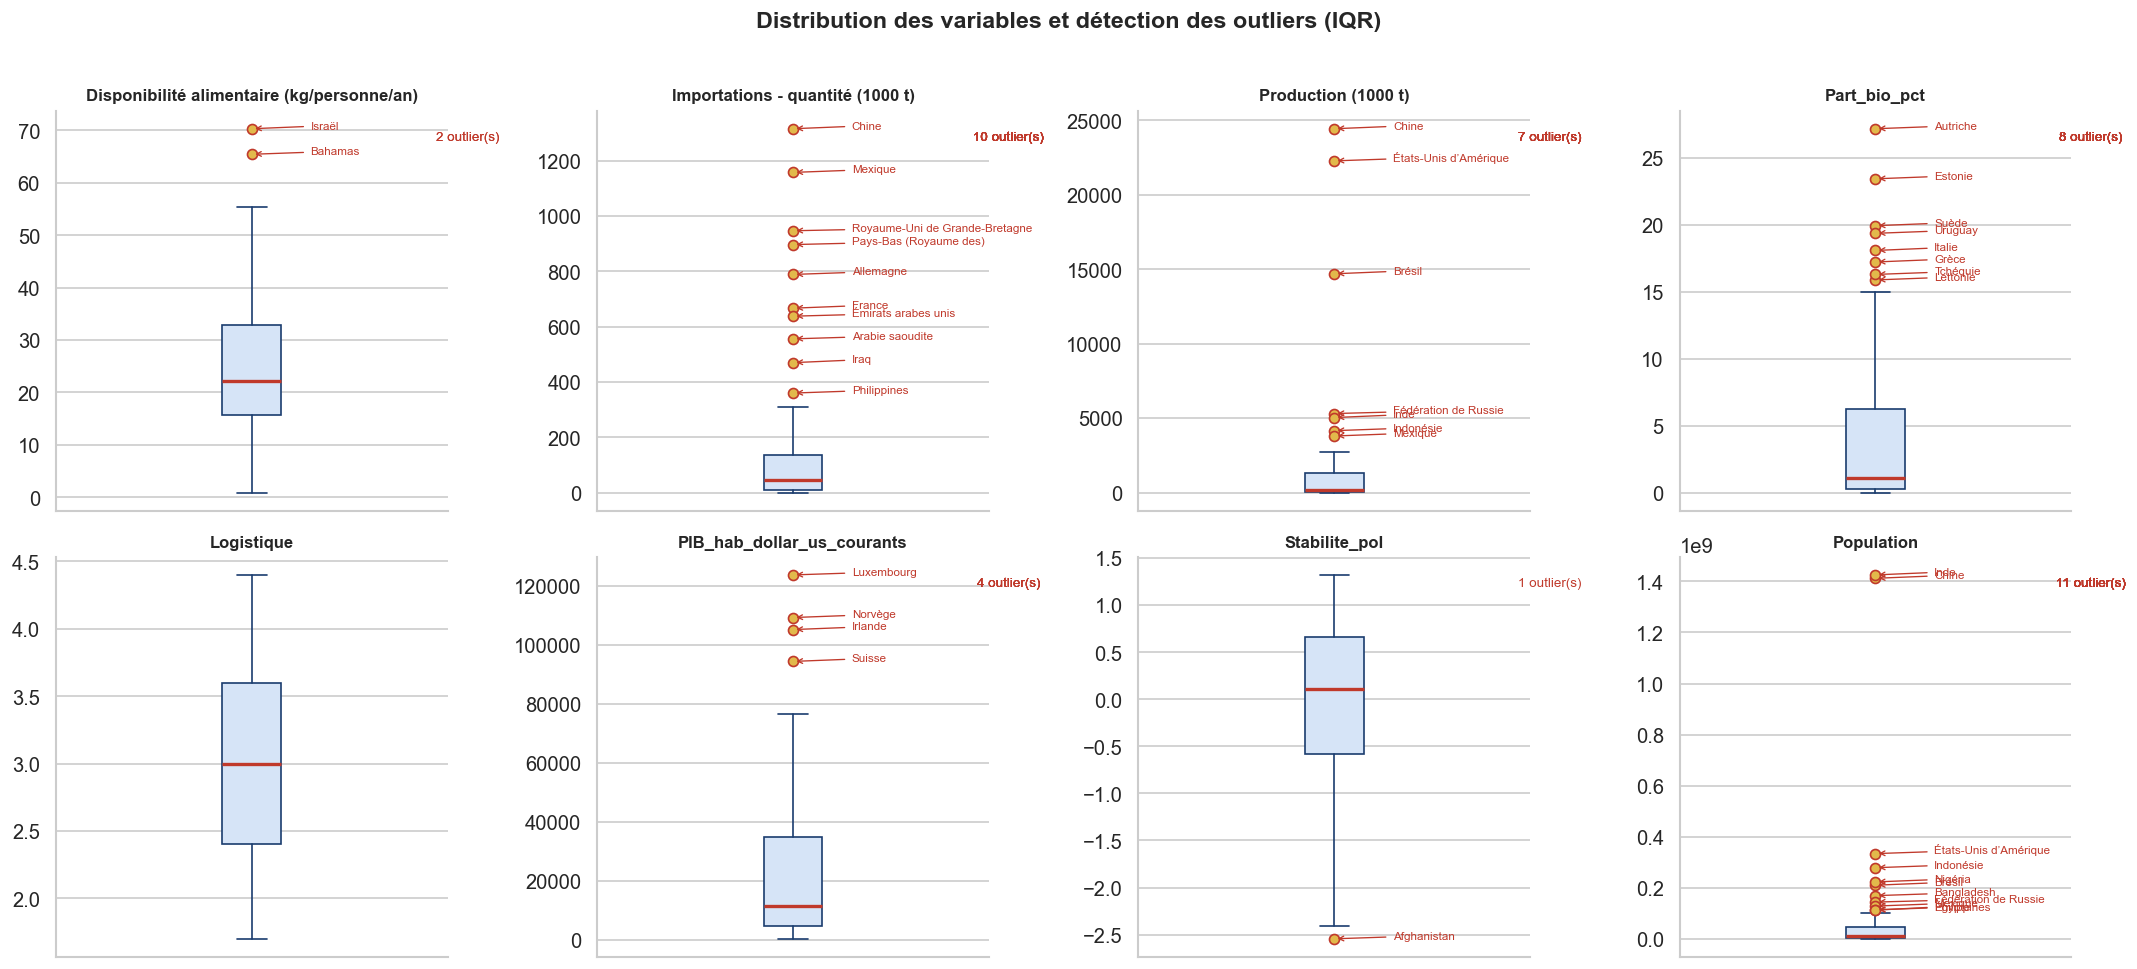

In [87]:
# Visualisation des outliers avec boxplots
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
cols_plot = num_cols
labels    = num_cols

for ax, col, lbl in zip(axes.flatten(), cols_plot, labels):
    mask, _, _ = iqr_outliers(df[col])
    bp = ax.boxplot(df[col].dropna(), patch_artist=True, notch=False,
                    medianprops={"color": RED, "linewidth":2},
                    boxprops={"facecolor": "#d6e4f7", "edgecolor": BLUE},
                    whiskerprops={"color": BLUE},
                    capprops={"color": BLUE},
                    flierprops={"marker":"o","markerfacecolor": GOLD,
                                "markersize":6, "markeredgecolor": RED})
    ax.set_title(lbl, fontsize=10, fontweight="bold")
    ax.set_xticks([])
    # Annoter les outliers : afficher le nombre d'outliers
    for idx in df[mask].index:
        ax.text(1.05, 0.95, f"{mask.sum()} outlier(s)", transform=ax.transAxes,
                fontsize=8, color=RED, ha="center", va="top")
    # Annoter les outliers : Affichers les pays les plus éloinnés des seuils (limite d'affichage pour éviter la surcharge visuelle)
    if mask.sum() > 0:
            for idx in df[mask].index:
                ax.annotate(df.loc[idx,"Pays"][:30],
                            xy=(1, df.loc[idx, col]), # Position de la flèche (x=1 pour la boîte du boxplot, y = valeur de l'outlier)
                            xytext=(1.15, df.loc[idx, col]), # Position du texte (décalé à droite de la boîte)
                            fontsize=7, color=RED,
                            arrowprops={"arrowstyle":"->", "color": RED, "lw": 0.8})


fig.suptitle("Distribution des variables et détection des outliers (IQR)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("data-output/N1-outliers_boxplots.png", bbox_inches="tight")
plt.show()

<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px">6.4 : Analyses univariées </h3>
</div>

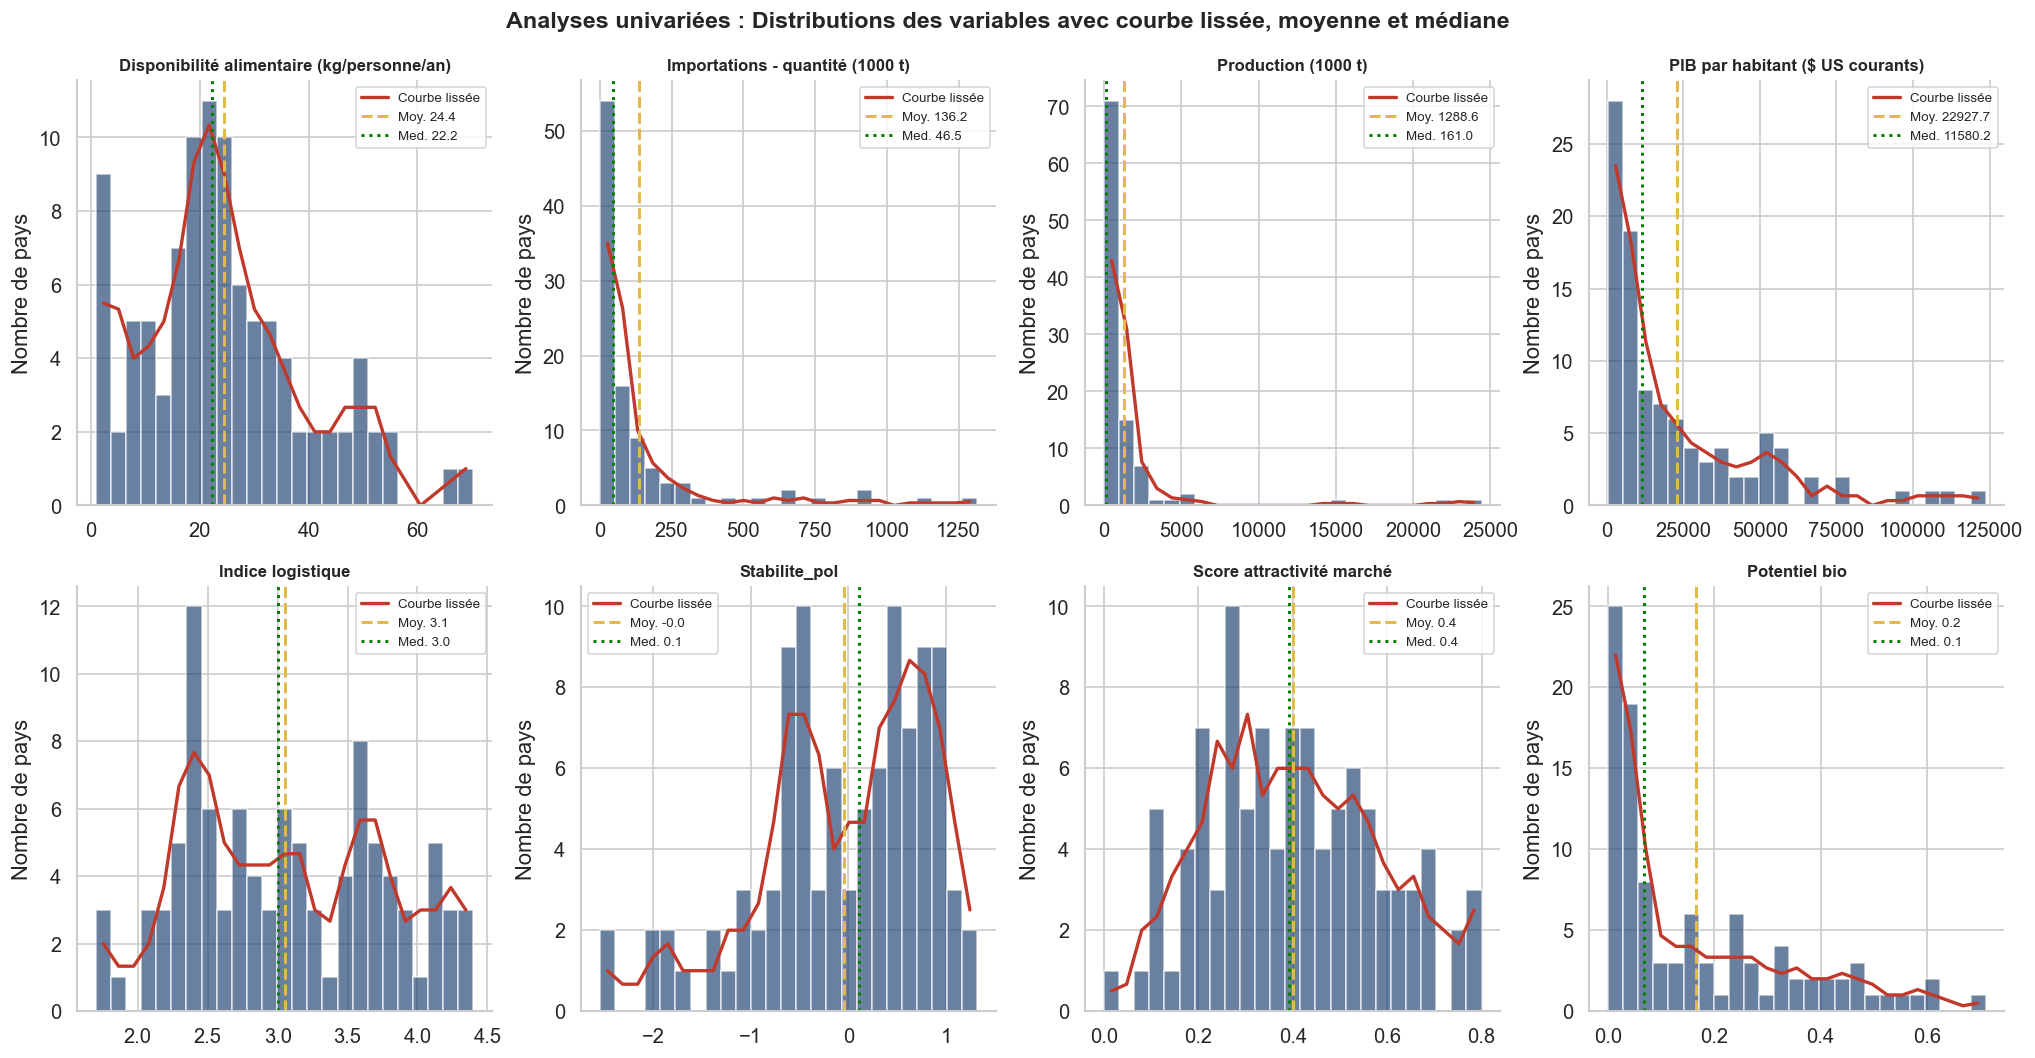

In [88]:
# Histogrammes des variables avec courbe lissée, moyenne et médiane
fig, axes = plt.subplots(2, 4, figsize=(17, 9))

vars_hist = ["Disponibilité alimentaire (kg/personne/an)",
            "Importations - quantité (1000 t)",
            "Production (1000 t)",
            "PIB_hab_dollar_us_courants",
            "Logistique",
            "Stabilite_pol",
            "Score_attractivite",
            "Potentiel_bio"]

titles   = ["Disponibilité alimentaire (kg/personne/an)",
            "Importations - quantité (1000 t)",
            "Production (1000 t)",
            "PIB par habitant ($ US courants)",
            "Indice logistique",
            "Stabilite_pol",
            "Score attractivité marché",
            "Potentiel bio"]

for ax, v, t in zip(axes.flatten(), vars_hist, titles):
    data = df[v].dropna()

    # Histogramme en comptage brut
    counts, edges, _ = ax.hist(data, bins=25, color=BLUE, alpha=0.65, edgecolor="white")

    # Centre de chaque barre
    centers = (edges[:-1] + edges[1:]) / 2



    # Moyenne mobile lissée (window=3)
    smooth = pd.Series(counts).rolling(window=3, center=True, min_periods=1).mean()
    ax.plot(centers, smooth, color=RED, linewidth=2, label="Courbe lissée")

    # Moyenne et médiane
    ax.axvline(data.mean(),   color=GOLD,    linewidth=1.8, linestyle="--", label=f"Moy. {data.mean():.1f}")
    ax.axvline(data.median(), color="green", linewidth=1.8, linestyle=":",  label=f"Med. {data.median():.1f}")

    ax.set_title(t, fontsize=10, fontweight="bold")
    ax.set_ylabel("Nombre de pays")
    ax.legend(fontsize=8)

fig.suptitle("Analyses univariées : Distributions des variables avec courbe lissée, moyenne et médiane",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("data-output/N1-univarie_histogrammes.png", bbox_inches="tight")
plt.show()

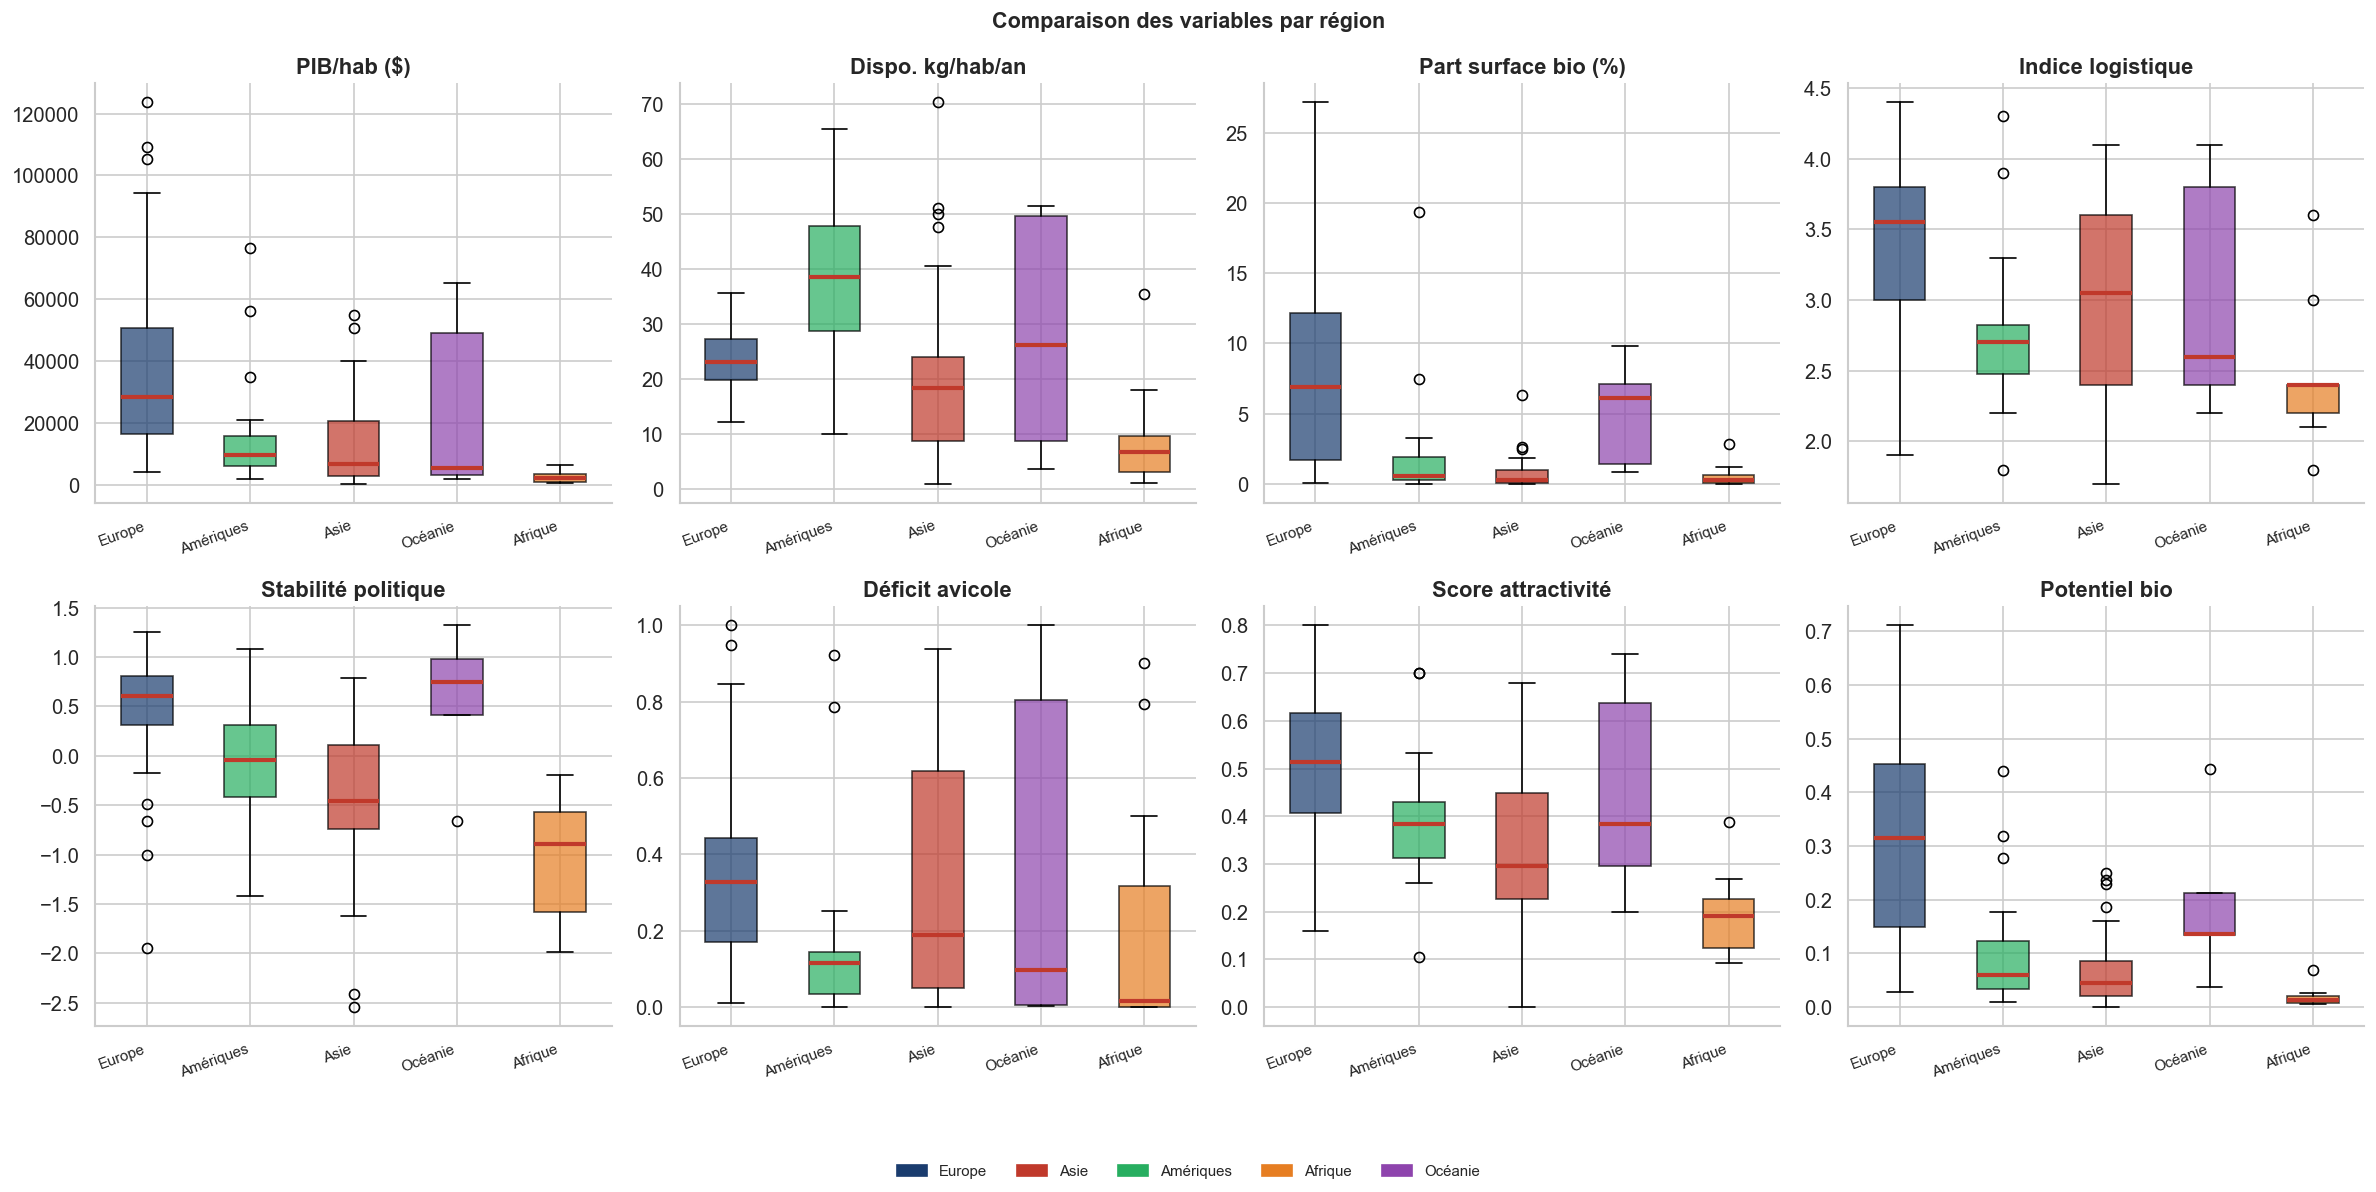

In [89]:
# Comparaison par région
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

metrics = [
    "PIB_hab_dollar_us_courants",
    "Disponibilité alimentaire (kg/personne/an)",
    "Part_bio_pct",
    "Logistique",
    "Stabilite_pol",
    "Deficit_avicole",
    "Score_attractivite",
    "Potentiel_bio"
]
mlabels = [
    "PIB/hab ($)",
    "Dispo. kg/hab/an",
    "Part surface bio (%)",
    "Indice logistique",
    "Stabilité politique",
    "Déficit avicole",
    "Score attractivité",
    "Potentiel bio"
]

region_order = df.groupby("Region")["PIB_hab_dollar_us_courants"].median().sort_values(ascending=False).index

for ax, m, ml in zip(axes.flatten(), metrics, mlabels):
    data_plot = [df.loc[df["Region"]==r, m].dropna().values for r in region_order]
    bp = ax.boxplot(data_plot, patch_artist=True,
                    medianprops={"color": RED, "linewidth":2.5})
    for patch, region in zip(bp["boxes"], region_order):
        patch.set_facecolor(PALETTE_REGION.get(region, "#aaa"))
        patch.set_alpha(0.7)
    ax.set_xticklabels(region_order, rotation=20, ha="right", fontsize=9)
    ax.set_title(ml, fontweight="bold")

# Légende régions
handles = [mpatches.Patch(color=v, label=k) for k,v in PALETTE_REGION.items()]
fig.legend(handles=handles, loc="lower center", ncol=5, frameon=False, fontsize=9)

fig.suptitle("Comparaison des variables par région", fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0,0.07,1,1])
plt.savefig("data-output/N1-univarie_regions.png", bbox_inches="tight")
plt.show()

In [90]:
df

,Year,Disponibilité alimentaire (kg/personne/an),Importations - quantité (1000 t),Production (1000 t),Pays,Region,M49 Code,ISO-alpha3 Code,Part_bio_pct,Logistique,PIB_hab_dollar_us_courants,Stabilite_pol,Population,PIB_hab_evol_18_22_pct,Deficit_avicole,Score_attractivite,Potentiel_bio
0,2022,0.87,7.0,29.0,Afghanistan,Asie,4,AFG,0.00,1.7,357.261153,-2.544956,40578842.0,-27.3,0.1944,0.0000,0.0000
1,2022,35.47,304.0,1958.0,Afrique du Sud,Afrique,710,ZAF,0.05,3.6,6534.248678,-0.681386,62378410.0,-5.5,0.1344,0.3887,0.0260
2,2022,22.68,47.0,18.0,Albanie,Europe,8,ALB,0.06,2.7,7756.961887,0.106261,2451636.0,31.5,0.7231,0.3321,0.0311
3,2022,9.71,0.0,443.0,Algérie,Afrique,12,DZA,0.00,2.1,4960.303343,-0.650652,45477389.0,8.4,0.0000,0.1917,0.0187
4,2022,16.63,789.0,1508.0,Allemagne,Europe,276,DEU,9.67,4.3,50506.517964,0.628492,83177813.0,3.3,0.3435,0.6223,0.3812
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2022,7.69,5.0,118.0,Zimbabwe,Afrique,716,ZWE,0.01,2.4,2536.400502,-0.894974,16069056.0,11.7,0.0407,0.1924,0.0090
96,2022,17.90,20.0,1999.0,Égypte,Afrique,818,EGY,2.86,3.0,4233.307837,-0.978701,112618250.0,70.4,0.0099,0.2694,0.0683
97,2022,47.53,638.0,47.0,Émirats arabes unis,Asie,784,ARE,1.38,4.1,50759.758923,0.744183,10074977.0,7.7,0.9314,0.6787,0.2297
98,2022,53.75,191.0,22272.0,États-Unis d’Amérique,Amériques,840,USA,0.49,3.9,76657.248884,0.008701,334017321.0,22.7,0.0085,0.6995,0.3183


<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px">6.5 Matrice de corrélation</h3>
</div>

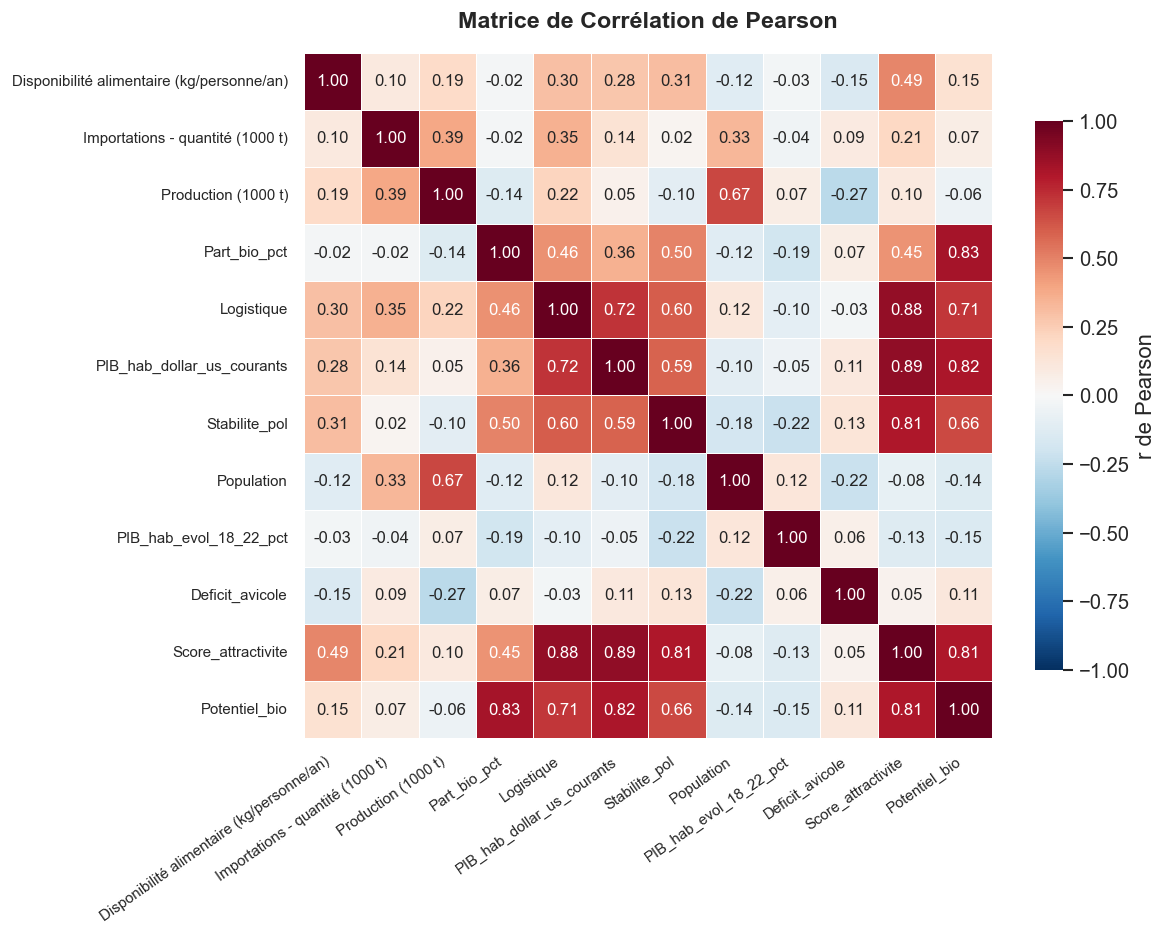

In [91]:
# Stockage de la liste des colonnes à analyser
cols_corr = ['Disponibilité alimentaire (kg/personne/an)',
       'Importations - quantité (1000 t)', 'Production (1000 t)',
       'Part_bio_pct', 'Logistique',
       'PIB_hab_dollar_us_courants', 'Stabilite_pol', 'Population',
       'PIB_hab_evol_18_22_pct', 'Deficit_avicole',
       'Score_attractivite', 'Potentiel_bio']

# Calcul de la matrice de corrélation de Pearson
corr_matrix = df[cols_corr].corr()

# Visualisation de la matrice de corrélation avec seaborn
fig, ax = plt.subplots(figsize=(10, 8)) # Taille de la figure

# Affichage de la heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1,
            linewidths=0.4, linecolor="white",
            annot_kws={"size": 10},
            cbar_kws={"shrink": 0.8, "label": "r de Pearson"},
            ax=ax)
ax.set_title("Matrice de Corrélation de Pearson", fontsize=14, fontweight="bold", pad=15)
plt.xticks(rotation=35, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("data-output/N1-correlation_matrix.png", bbox_inches="tight")
plt.show()